# Sweep Results
Loads all `best.pt` checkpoints and visualizes val loss and 2AFC across hyperparameters.

In [14]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR

# ── swept hyperparameter grids — keyed by (model, target) ────────────────────
SWEEP_PARAMS = {
    ("mlp", "siglip"): {
        "bottleneck":   {64, 128, 256},
        "dropout":      {0.1},
        "lr":           {1e-3, 3e-4},
        "weight_decay": {1e-2, 1e-1},
    },
    ("mlp", "clip"): {
        "bottleneck":   {64, 128, 256},
        "dropout":      {0.1},
        "lr":           {1e-3, 3e-4},
        "weight_decay": {1e-2, 1e-1},
    },
    ("lstm", "siglip"): {
        "hidden":       {64, 128, 256},
        "n_layers":     {1, 2},
        "dropout":      {0.1},
        "lr":           {1e-3, 3e-4},
        "weight_decay": {1e-2, 1e-1},
    },
    ("lstm", "clip"): {
        "hidden":       {64, 128, 256, 512},
        "n_layers":     {1, 2},
        "dropout":      {0.1},
        "lr":           {1e-3, 3e-4},
        "weight_decay": {1e-2, 1e-1},
    },
    ("transformer", "siglip"): {
        "d_model":      {64, 128},
        "n_layers":     {1, 2, 4},
        "dropout":      {0.1},
        "lr":           {1e-3, 3e-4},
        "weight_decay": {1e-2, 1e-1},
    },
    ("transformer", "clip"): {
        "d_model":      {32, 64, 128, 512},
        "n_layers":     {1, 2, 4},
        "dropout":      {0.1},
        "lr":           {1e-3, 3e-4},
        "weight_decay": {1e-2},
    },
}

ENCODER_MODELS  = ["mlp", "lstm", "transformer"]
ENCODER_TARGETS = ["siglip", "clip"]

candidates = []
for model_name in ENCODER_MODELS:
    for tgt in ENCODER_TARGETS:
        pattern_dir = CHECKPOINT_DIR / model_name / tgt
        if not pattern_dir.exists():
            pattern_dir = CHECKPOINT_DIR / model_name
        candidates.extend((tgt, model_name, pt) for pt in sorted(pattern_dir.glob("*/best.pt")))

def _in_sweep(args: dict, model_name: str, tgt: str) -> bool:
    grid = SWEEP_PARAMS.get((model_name, tgt), {})
    for param, allowed in grid.items():
        val = args.get(param)
        if val is None:
            continue
        if not any(abs(float(val) - a) < 1e-9 for a in allowed):
            return False
    return True

def load_one(item):
    tgt, model_name, pt = item
    try:
        ckpt = torch.load(pt, weights_only=False, map_location="cpu")
    except Exception as e:
        return None, (pt, str(e))
    if "metrics" not in ckpt:
        return None, None
    args = ckpt["args"]
    if "target" not in args:
        args["target"] = tgt
    if not _in_sweep(args, model_name, tgt):
        return None, None
    # infer loss from path if not stored (older checkpoints default to infonce)
    if "loss" not in args or args["loss"] is None:
        args["loss"] = "cosine" if "losscosine" in str(pt) else "infonce"
    row = {**args, **ckpt["metrics"], "path": str(pt)}
    if "test_metrics" in ckpt:
        row.update(ckpt["test_metrics"])
    return row, None

records, skipped = [], []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, c): c for c in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Loading checkpoints"):
        row, err = fut.result()
        if err:
            skipped.append(err)
        elif row:
            records.append(row)

if skipped:
    print(f"Skipped {len(skipped)} unreadable checkpoints:")
    for pt, err in skipped:
        print(f"  {pt.name}: {err}")

df = pd.DataFrame(records)
has_test = all(c in df.columns for c in ["test_2afc", "test_top1", "test_top5", "test_top10"])
print(f"{len(df)} runs loaded  |  test_metrics present: {has_test}")
print(df.groupby(["model", "target", "loss"]).size().to_string())
df.head()

Loading checkpoints:   0%|          | 0/259 [00:00<?, ?it/s]

Skipped 16 unreadable checkpoints:
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading zip archive: failed finding central directory
  best.pt: PytorchStreamReader failed reading

,model,target,bottleneck,hidden,d_model,n_heads,n_layers,dropout,target_noise,epochs,...,train_loss,val_loss,val_2afc,path,test_2afc,test_top1,test_top5,test_top10,test_cos_sim,val_cos_sim
0,mlp,siglip,128,128,128,4,1,0.1,0.02,150,...,1.578011,3.516424,0.775510,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...,0.793878,0.02,0.38,0.60,-0.331959,NaN
1,mlp,siglip,128,128,128,4,1,0.1,0.02,150,...,1.641518,3.525723,0.775918,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...,0.810612,0.10,0.32,0.60,-0.339867,NaN
2,mlp,siglip,128,128,128,4,1,0.1,0.02,150,...,0.746803,3.354832,0.820816,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...,0.820408,0.16,0.42,0.66,-0.402479,NaN
3,mlp,siglip,128,128,128,4,1,0.1,0.02,150,...,1.162324,3.425464,0.789796,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...,0.800408,0.12,0.38,0.64,-0.326266,NaN
4,mlp,siglip,256,128,128,4,1,0.1,0.02,150,...,0.814262,3.349390,0.817959,/home/yy3658/NeurObjectGen/checkpoints/mlp/sig...,0.828163,0.12,0.50,0.72,-0.395871,NaN


In [15]:
def make_arch(row):
    m = row["model"]
    if m == "mlp":
        return f"bn{int(row['bottleneck'])}"
    elif m == "lstm":
        return f"h{int(row['hidden'])}"
    else:
        return f"d{int(row['d_model'])}_nl{int(row['n_layers'])}"

df["arch"]  = df.apply(make_arch, axis=1)
df["label"] = df.apply(
    lambda r: f"[{r['target']}] {r['model']} {make_arch(r)} do={r['dropout']} lr={r['lr']:.0e} wd={r['weight_decay']:.0e}",
    axis=1,
)

TARGETS  = sorted(df["target"].unique())
MODELS   = sorted(df["model"].unique())
LOSSES   = sorted(df["loss"].unique()) if "loss" in df.columns else ["infonce"]

TARGET_PALETTE = {"siglip": "tab:blue", "clip": "tab:orange"}
MODEL_PALETTE  = dict(zip(MODELS, ["tab:blue", "tab:orange", "tab:green"]))
# solid line / filled marker = infonce, dashed / open marker = cosine
LOSS_STYLE = {
    "infonce": dict(linestyle="-",  marker="o", facecolor=None,  label_suffix=""),
    "cosine":  dict(linestyle="--", marker="s", facecolor="none", label_suffix=" (cosine)"),
}

print(f"Targets: {TARGETS}  |  Models: {MODELS}  |  Losses: {LOSSES}")

Targets: ['clip', 'siglip']  |  Models: ['lstm', 'mlp', 'transformer']  |  Losses: ['cosine', 'infonce']


## Best run per model × target

In [16]:
cols = ["target", "model", "loss", "arch", "dropout", "lr", "weight_decay", "epoch",
        "train_loss", "val_loss", "val_2afc",
        "test_2afc", "test_top1", "test_top5", "test_top10"]
available = [c for c in cols if c in df.columns]
summary = (
    df.sort_values("val_2afc", ascending=False)
      .groupby(["target", "model", "loss"], sort=False)
      .first()
      .reset_index()
)[available]
summary

,target,model,loss,arch,dropout,lr,weight_decay,epoch,train_loss,val_loss,val_2afc,test_2afc,test_top1,test_top5,test_top10
0,siglip,transformer,infonce,d128_nl1,0.1,0.0003,0.01,92,1.190897,3.255998,0.840408,0.792653,0.14,0.48,0.64
1,siglip,mlp,infonce,bn256,0.1,0.0010,0.01,108,0.607607,3.337417,0.832245,0.819592,0.12,0.46,0.70
2,siglip,lstm,infonce,h256,0.1,0.0010,0.01,59,1.044268,3.265257,0.813469,0.765306,0.14,0.36,0.46
3,siglip,transformer,cosine,d128_nl1,0.1,0.0010,0.01,71,0.135039,0.265280,0.762449,0.735510,0.10,0.32,0.50
4,clip,transformer,infonce,d128_nl1,0.1,0.0010,0.01,74,0.755382,39.360542,0.726939,0.604898,0.04,0.12,0.32
5,clip,transformer,cosine,d128_nl1,0.1,0.0010,0.01,32,0.065689,0.640116,0.717551,0.724898,0.06,0.22,0.48
6,clip,lstm,infonce,h128,0.1,0.0010,0.01,60,2.221720,41.448837,0.716327,0.655102,0.02,0.22,0.42
7,clip,mlp,infonce,bn256,0.1,0.0003,0.01,121,2.564934,50.947826,0.655918,0.591020,0.02,0.16,0.30


## Val 2AFC vs Test 2AFC — faceted by target, coloured by model

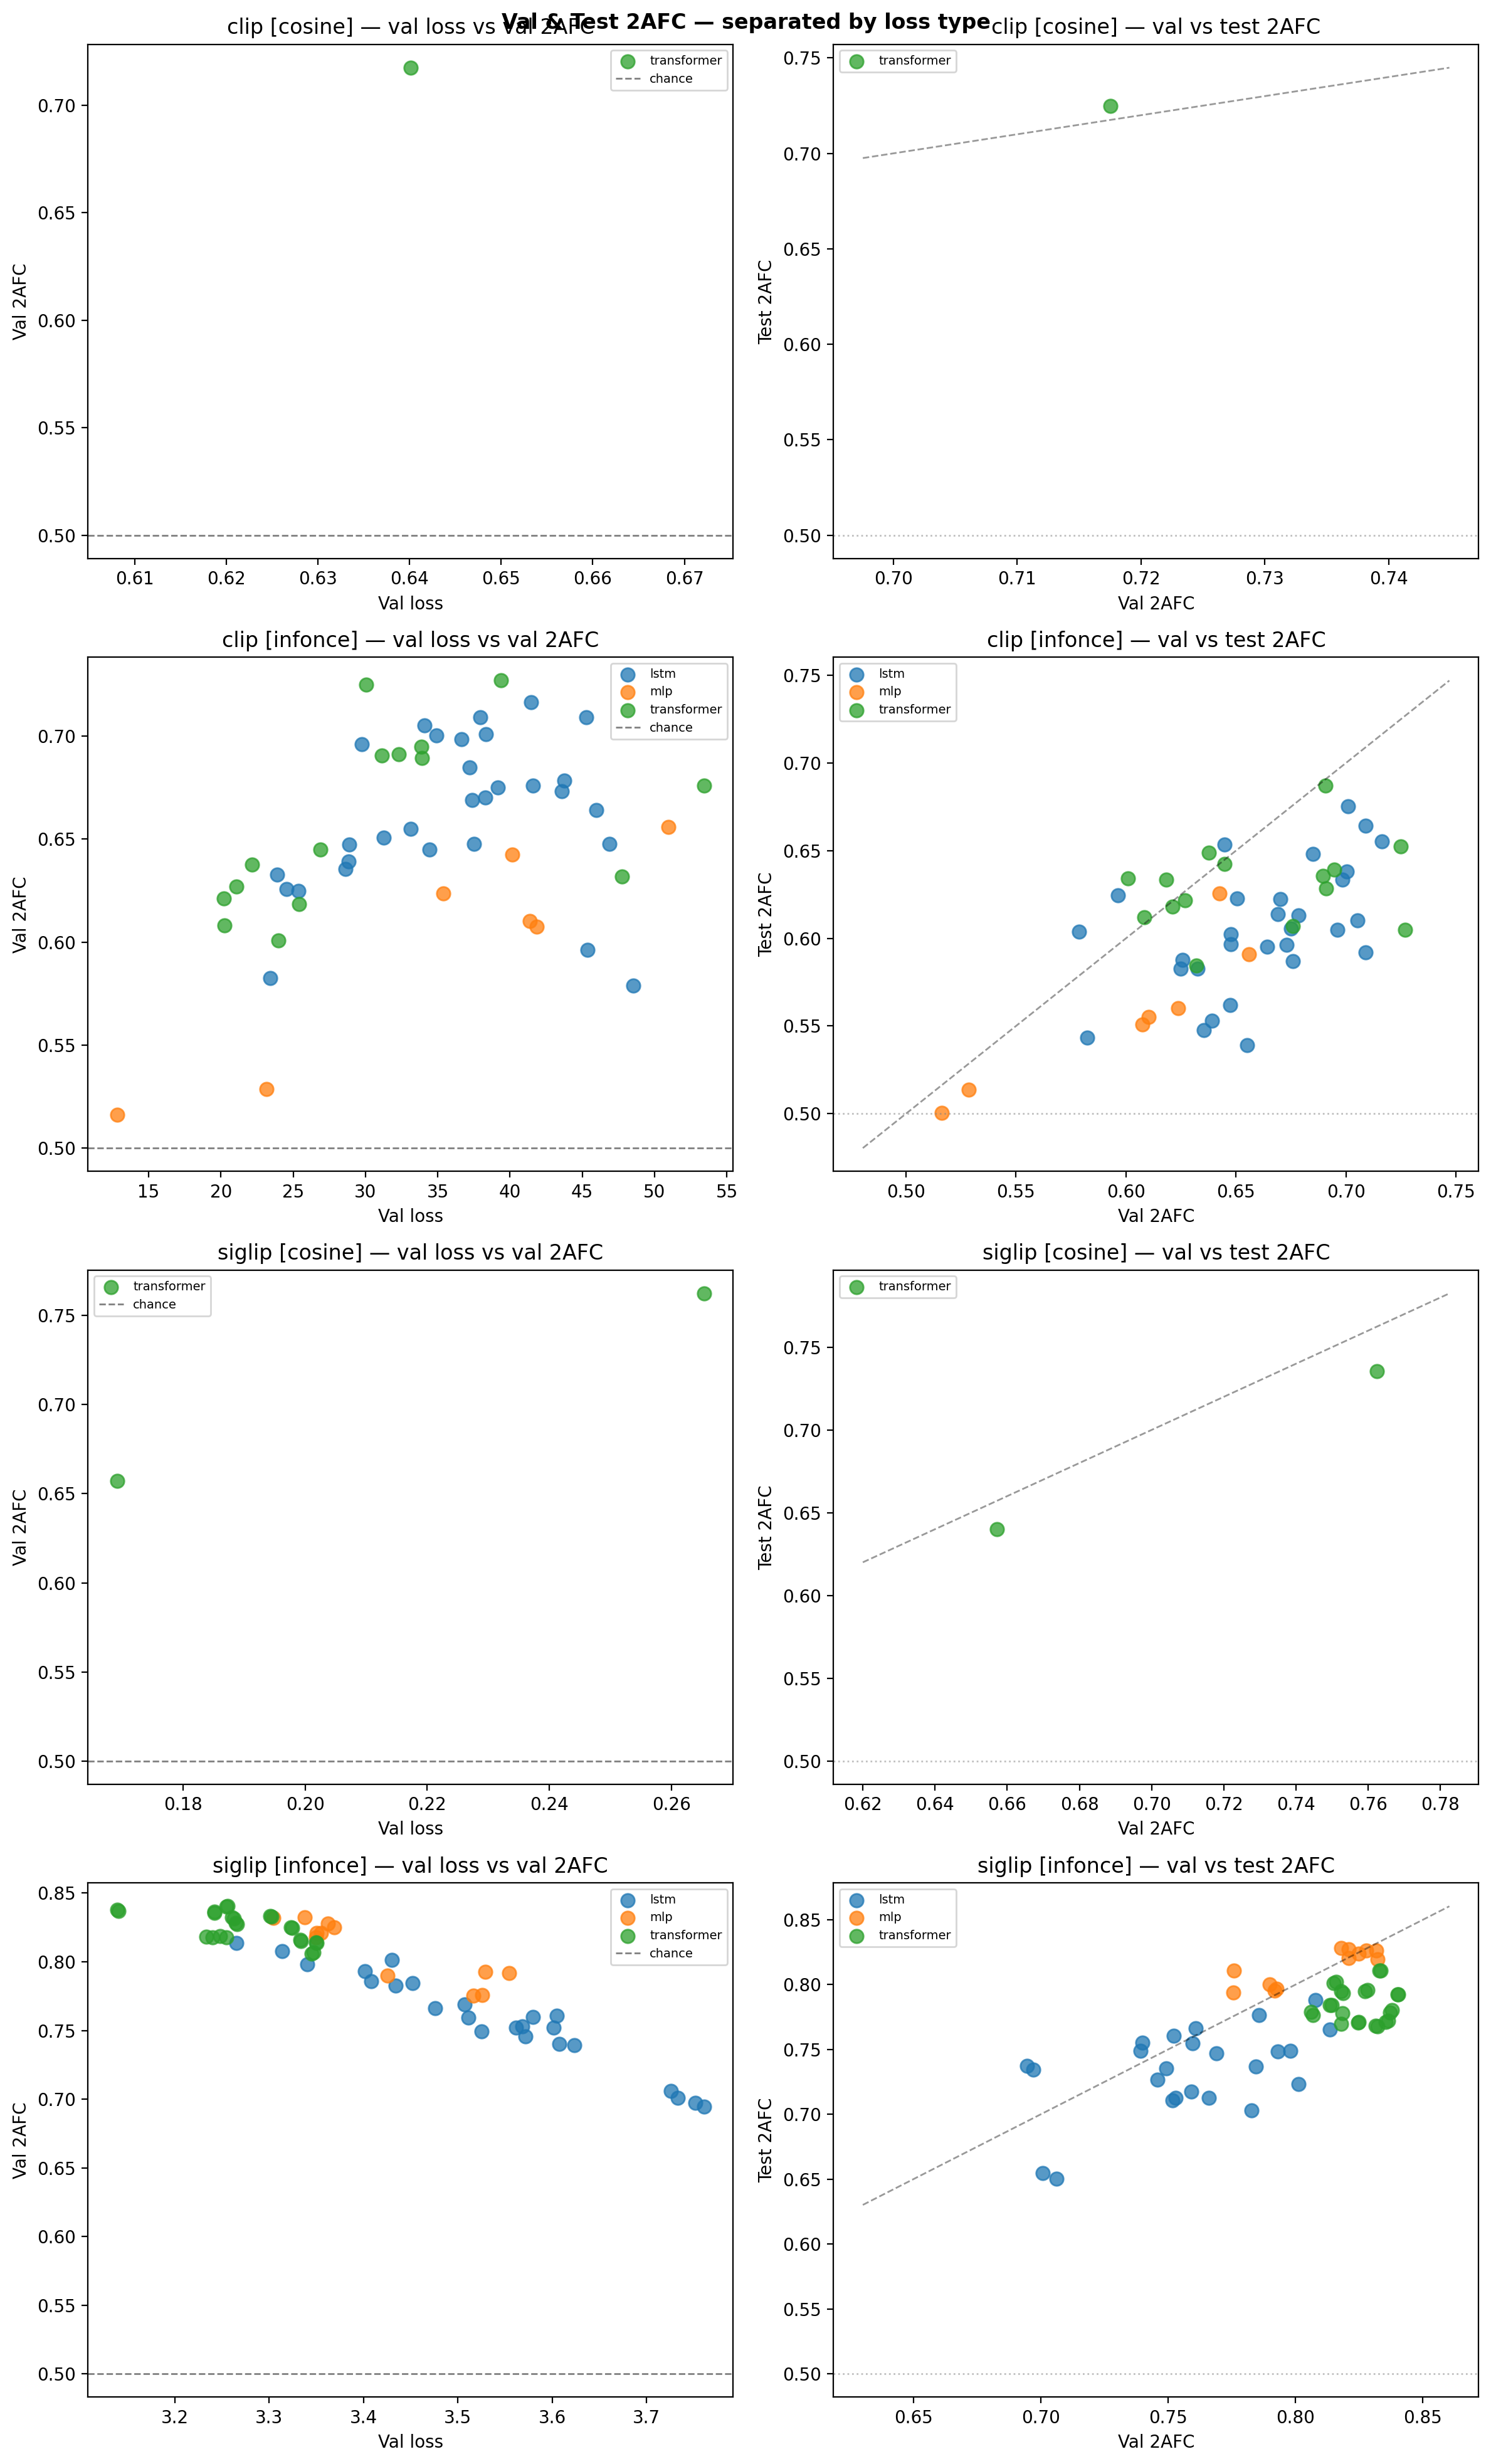

In [24]:
if has_test:
    fig, axes = plt.subplots(len(TARGETS) * len(LOSSES), 2,
                             figsize=(12, 5 * len(TARGETS) * len(LOSSES)), squeeze=False)
    for row_i, (tgt, loss) in enumerate([(t, l) for t in TARGETS for l in LOSSES]):
        sub = df[(df["target"] == tgt) & (df["loss"] == loss)].dropna(subset=["test_2afc"])

        ax = axes[row_i, 0]
        for model, grp in sub.groupby("model"):
            color = MODEL_PALETTE[model]
            ax.scatter(grp["val_loss"], grp["val_2afc"],
                       label=model, color=color, alpha=0.75, s=60)
        ax.axhline(0.5, color="grey", lw=1, ls="--", label="chance")
        ax.set_xlabel("Val loss")
        ax.set_ylabel("Val 2AFC")
        ax.set_title(f"{tgt} [{loss}] — val loss vs val 2AFC")
        ax.legend(fontsize=7)

        ax = axes[row_i, 1]
        for model, grp in sub.groupby("model"):
            color = MODEL_PALETTE[model]
            ax.scatter(grp["val_2afc"], grp["test_2afc"],
                       label=model, color=color, alpha=0.75, s=60)
        if len(sub):
            lim = [min(sub["val_2afc"].min(), sub["test_2afc"].min()) - 0.02,
                   max(sub["val_2afc"].max(), sub["test_2afc"].max()) + 0.02]
            ax.plot(lim, lim, "k--", lw=1, alpha=0.4)
        ax.axhline(0.5, color="grey", lw=1, ls=":", alpha=0.5)
        ax.set_xlabel("Val 2AFC")
        ax.set_ylabel("Test 2AFC")
        ax.set_title(f"{tgt} [{loss}] — val vs test 2AFC")
        ax.legend(fontsize=7)

    fig.suptitle("Val & Test 2AFC — separated by loss type", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(len(TARGETS), len(LOSSES),
                             figsize=(6 * len(LOSSES), 5 * len(TARGETS)), squeeze=False)
    for ri, tgt in enumerate(TARGETS):
        for ci, loss in enumerate(LOSSES):
            ax = axes[ri, ci]
            sub = df[(df["target"] == tgt) & (df["loss"] == loss)]
            for model, grp in sub.groupby("model"):
                ax.scatter(grp["val_loss"], grp["val_2afc"],
                           label=model, color=MODEL_PALETTE[model], alpha=0.75, s=60)
            ax.axhline(0.5, color="grey", lw=1, ls="--", label="chance")
            ax.set_xlabel("Val loss")
            ax.set_ylabel("Val 2AFC")
            ax.set_title(f"{tgt} [{loss}]")
            ax.legend(fontsize=7)
    fig.suptitle("Val loss vs 2AFC — separated by loss type", fontweight="bold")
    plt.tight_layout()
    plt.show()

## 2AFC by hyperparameter — per model × target (val and test)

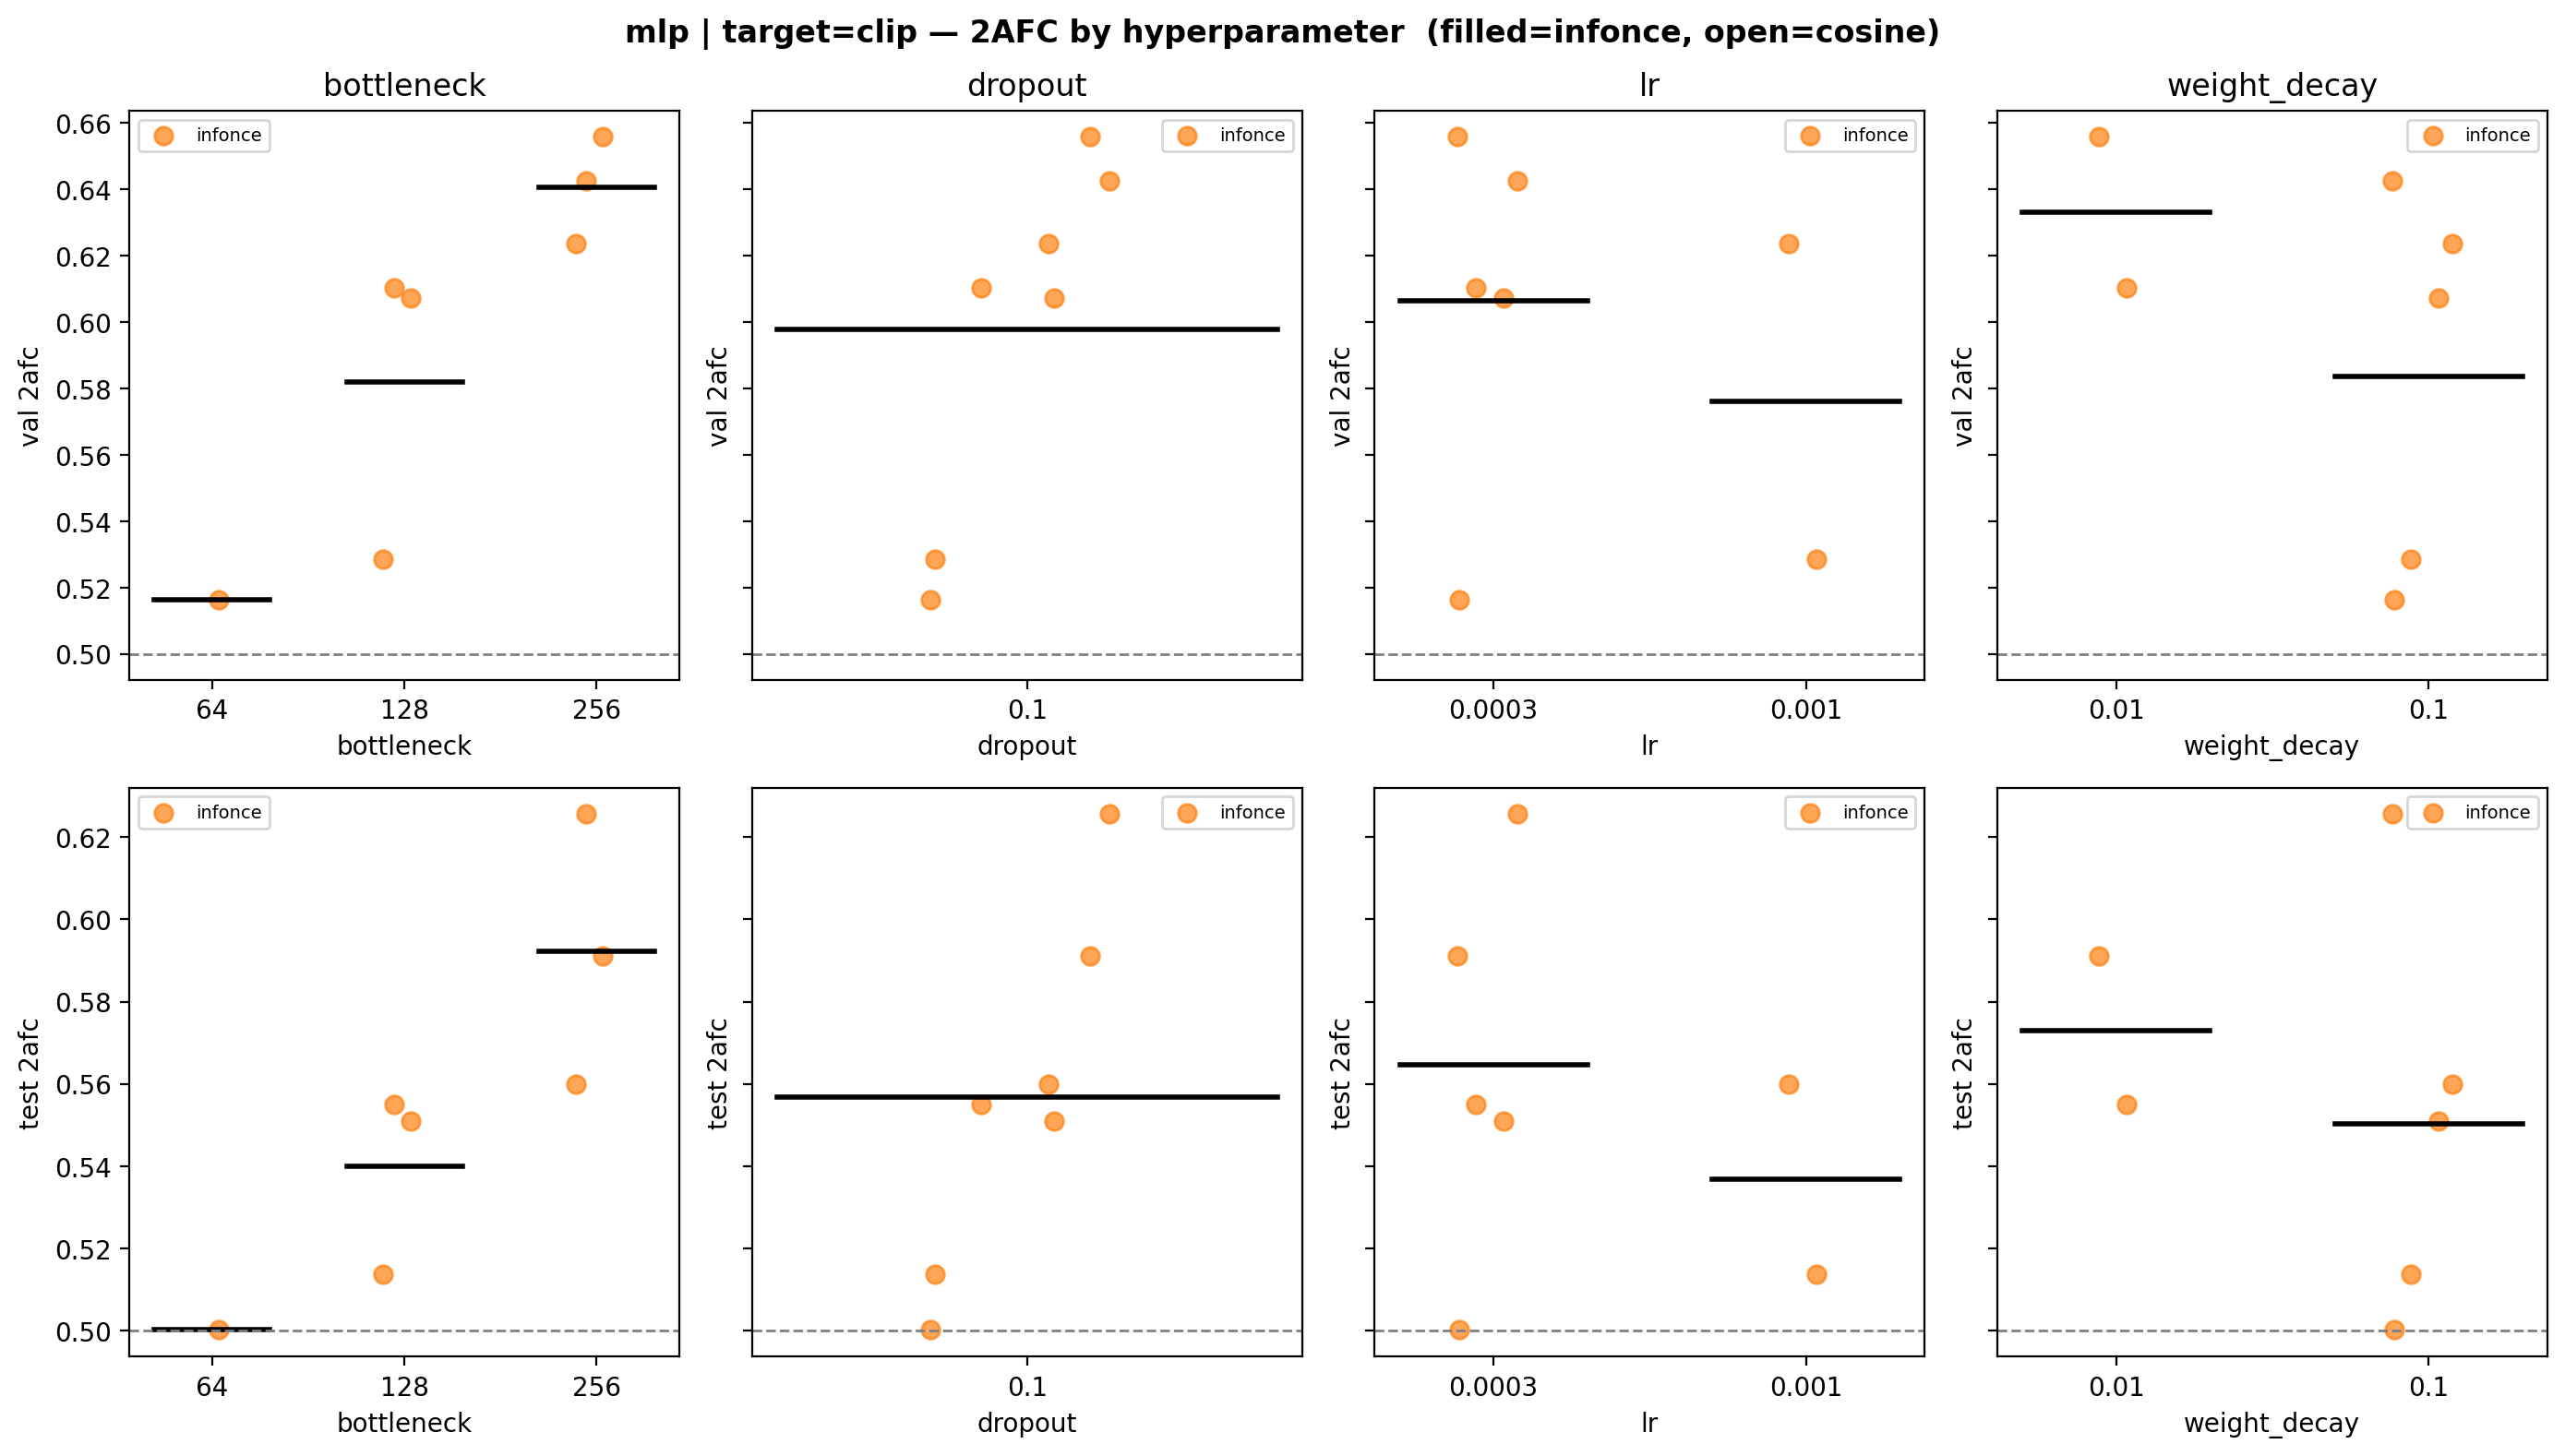

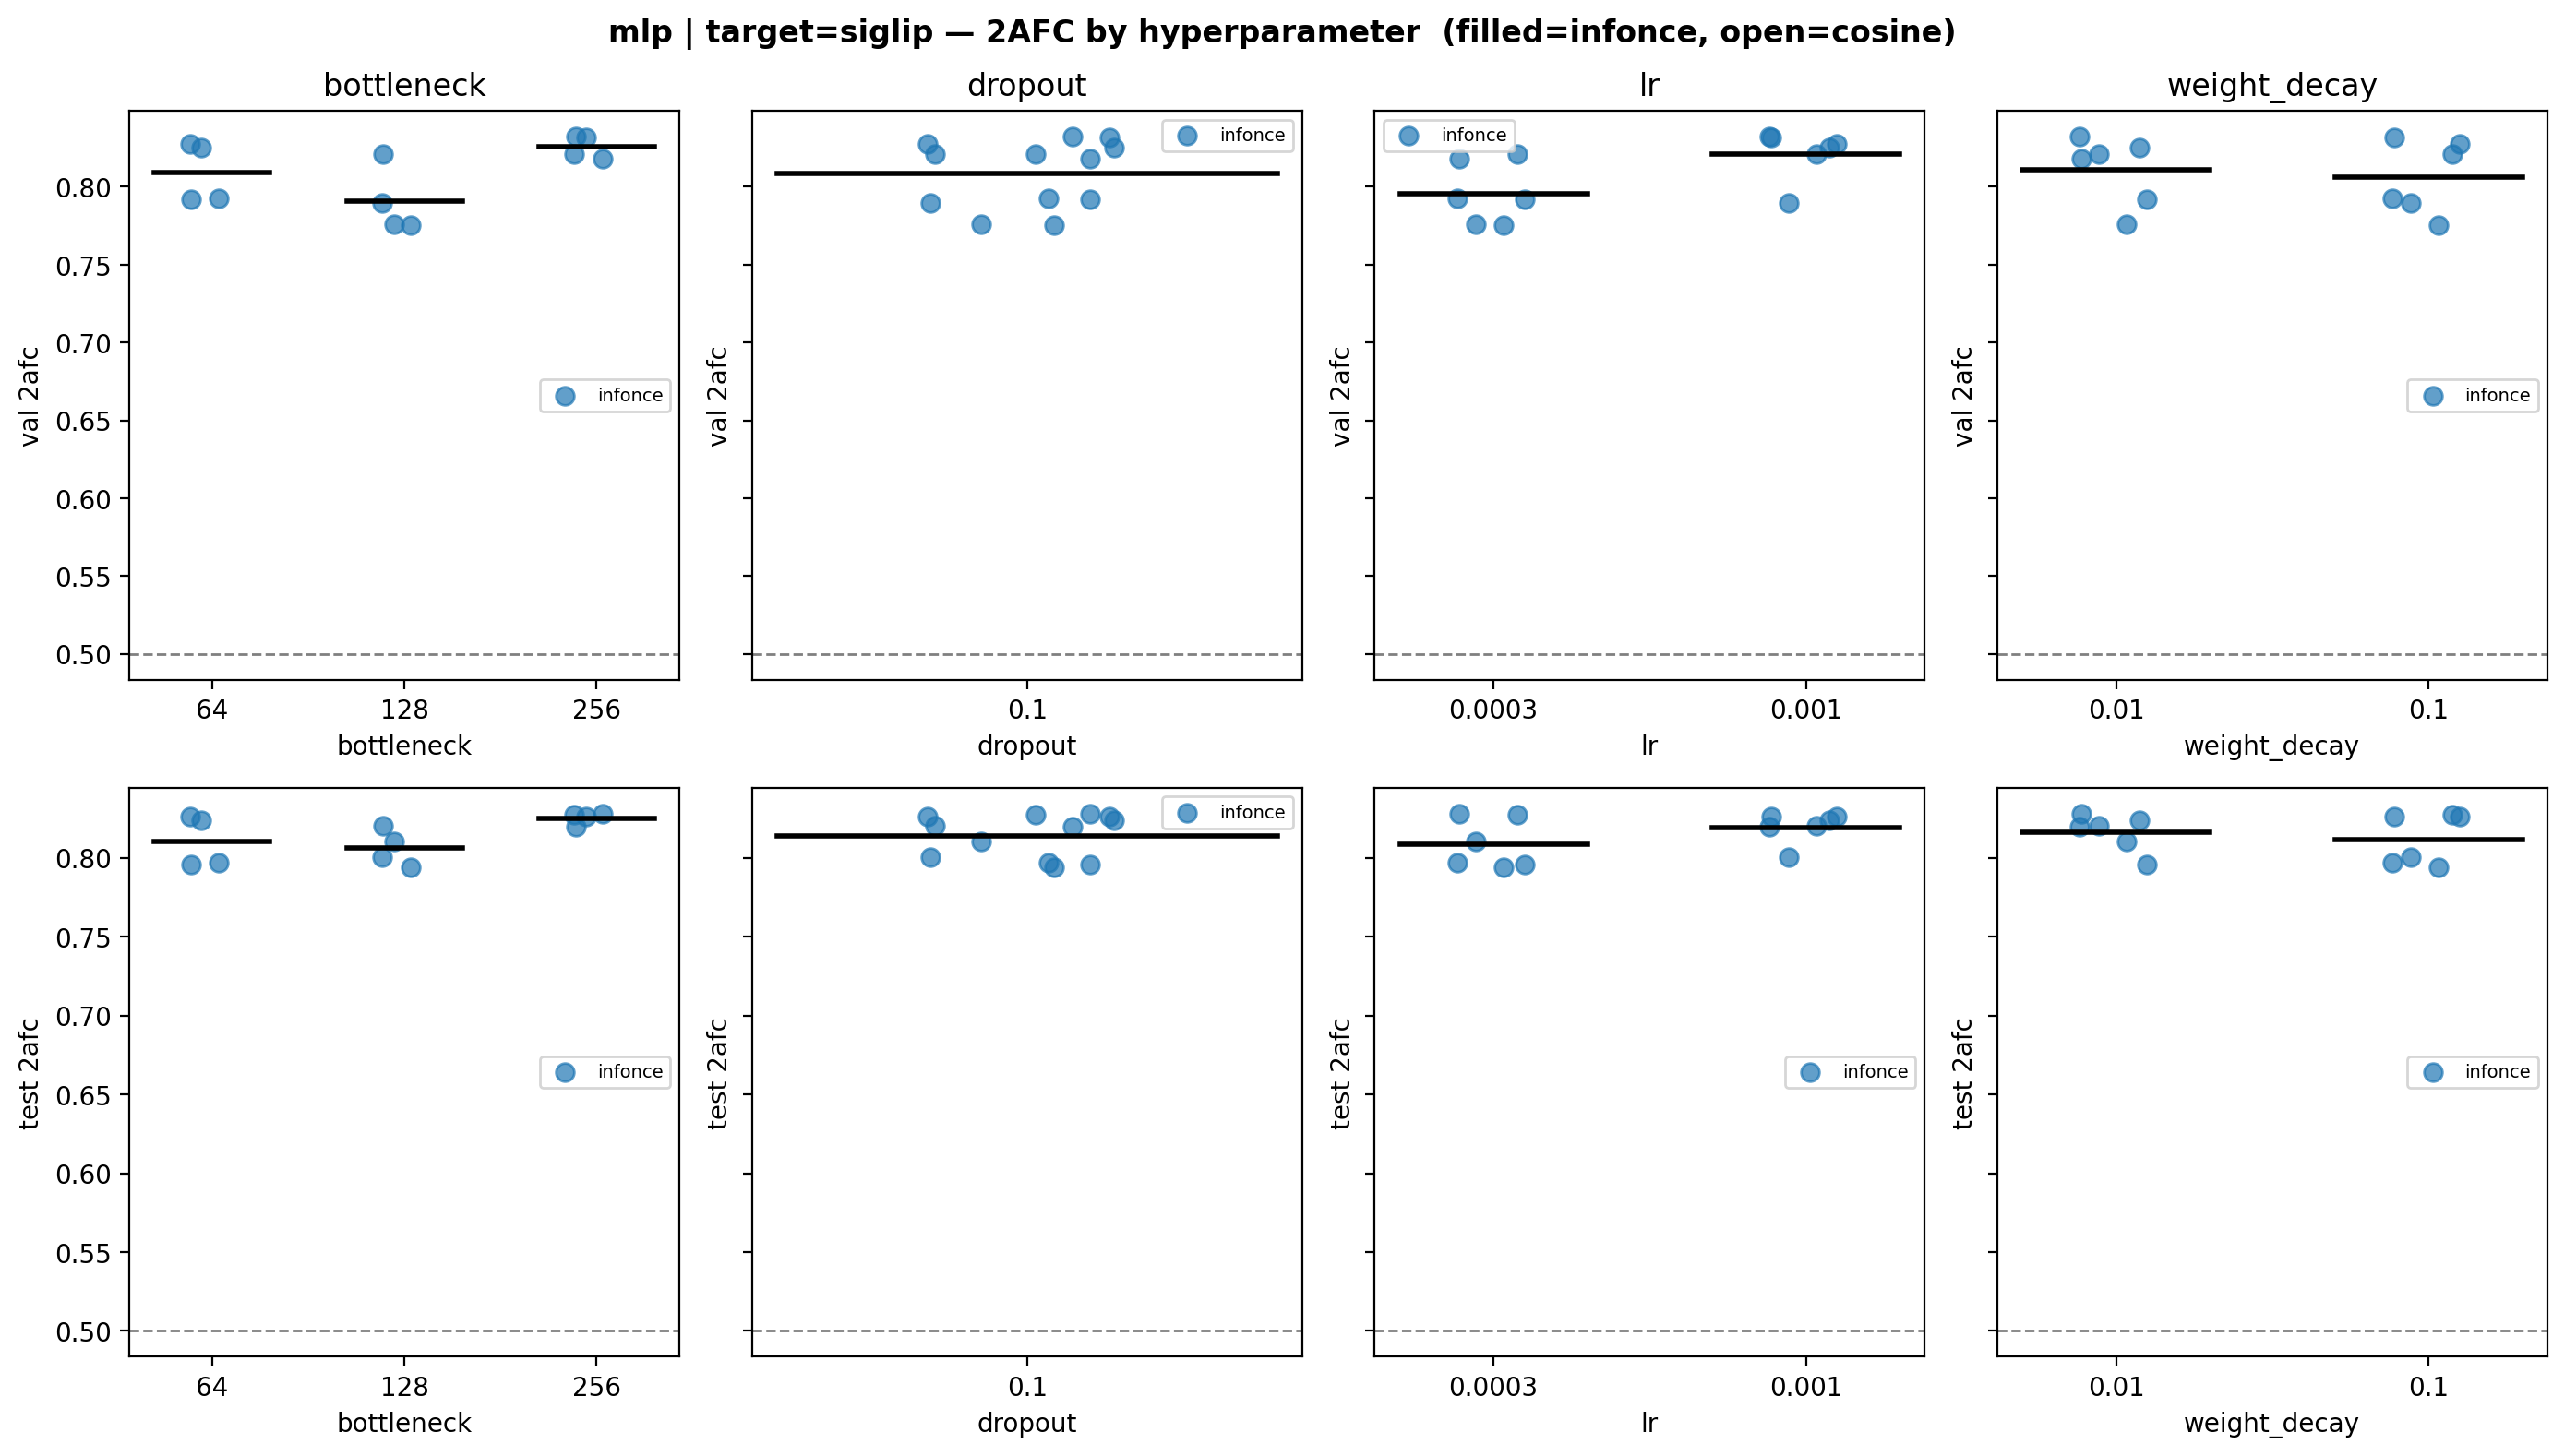

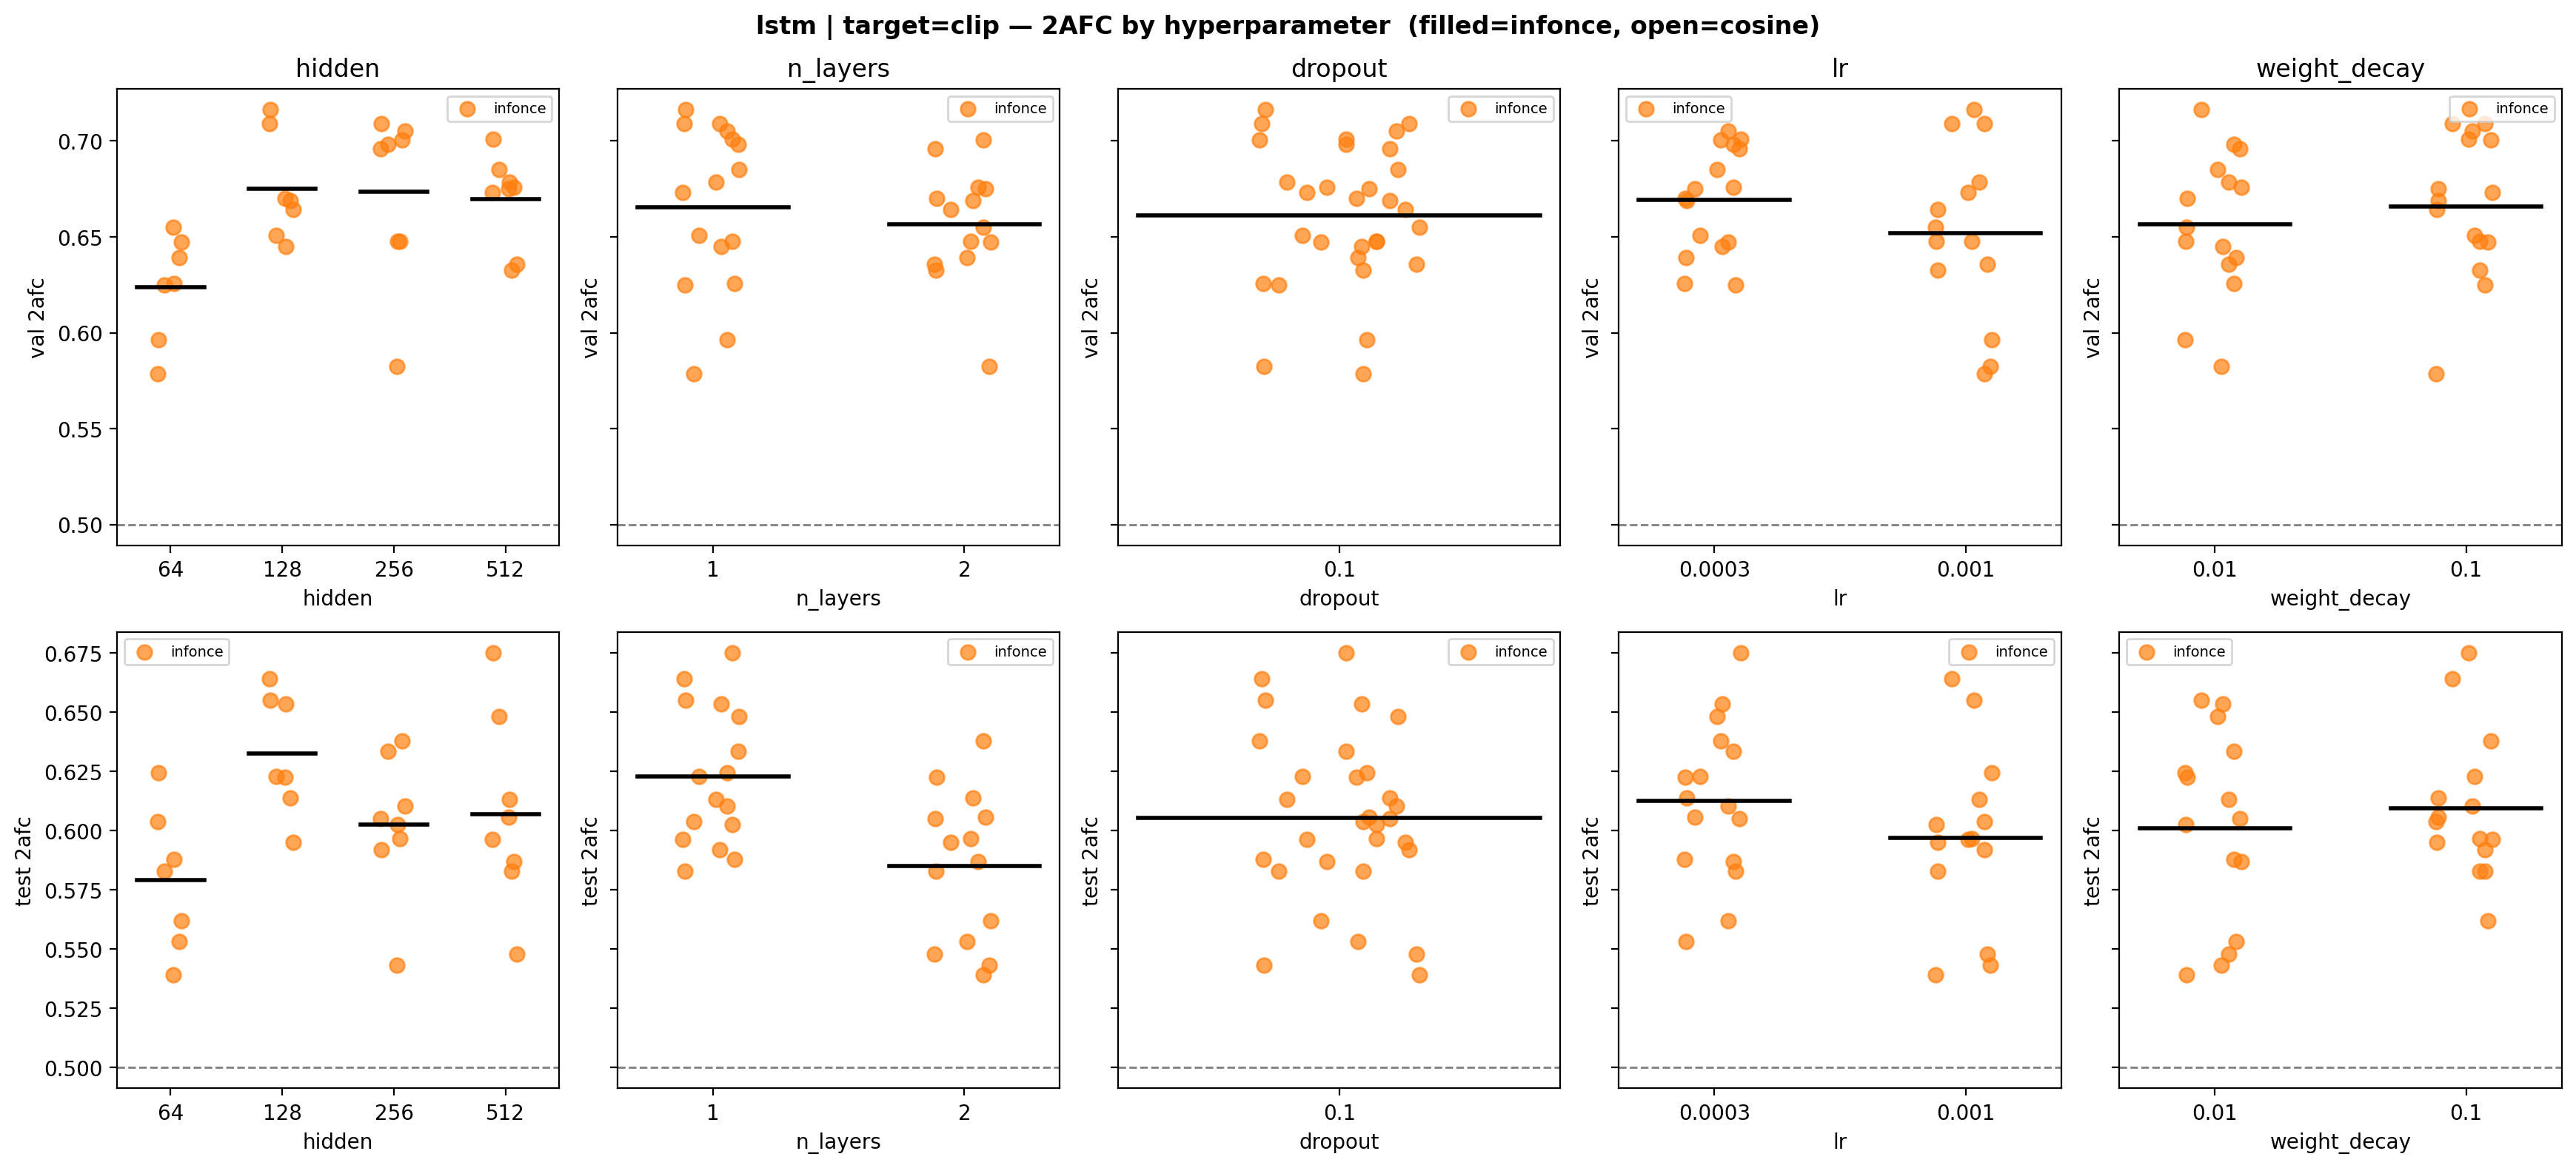

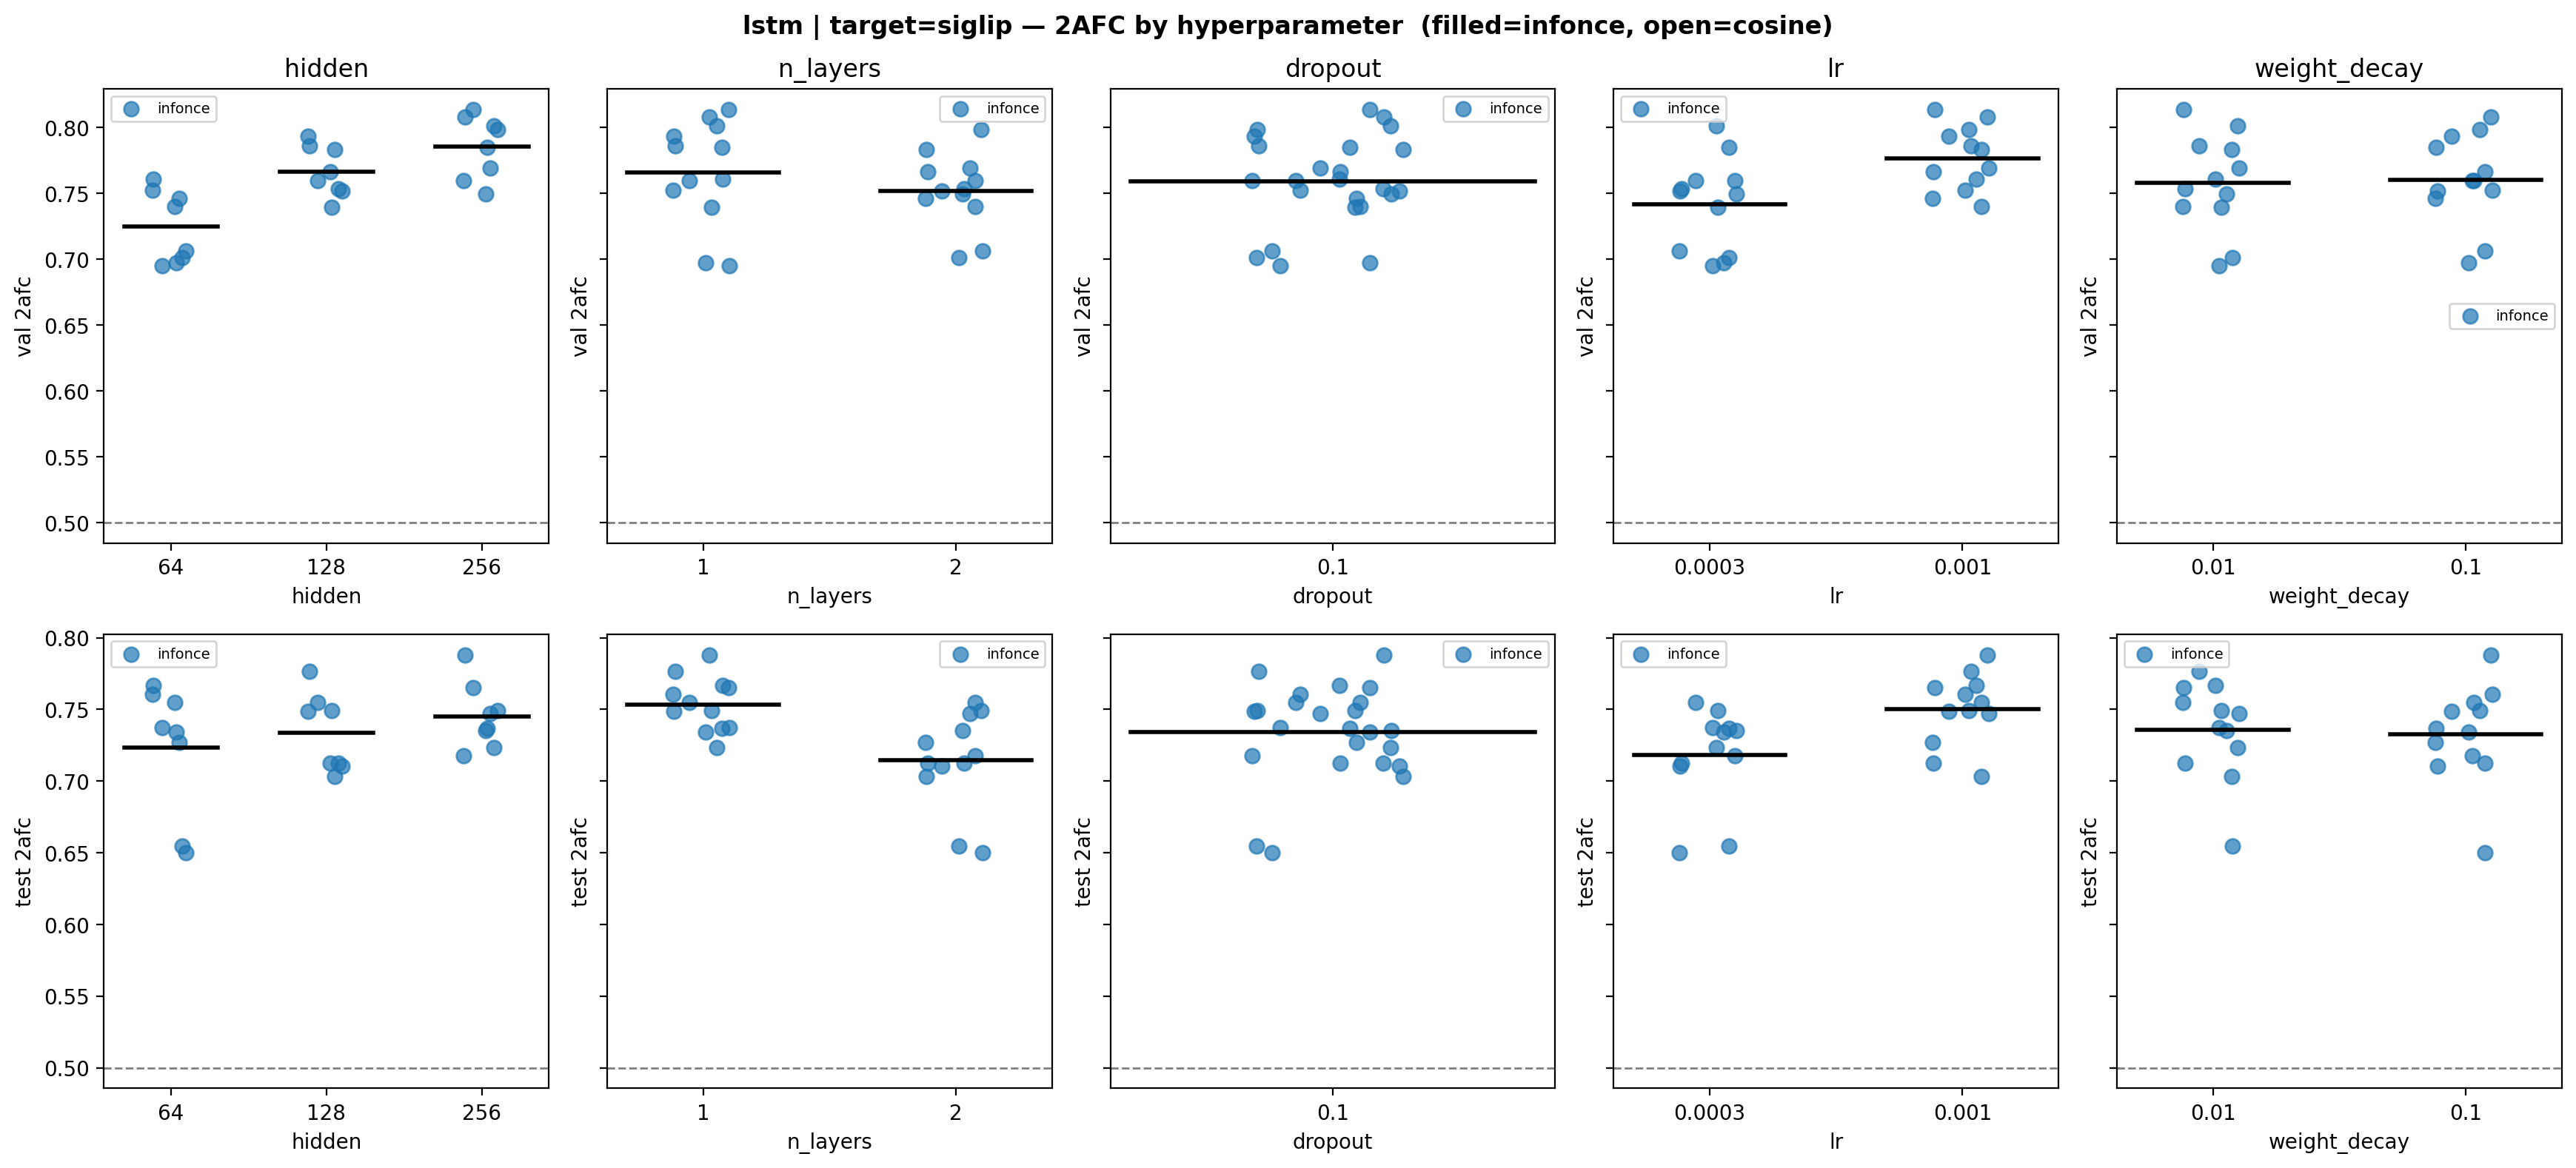

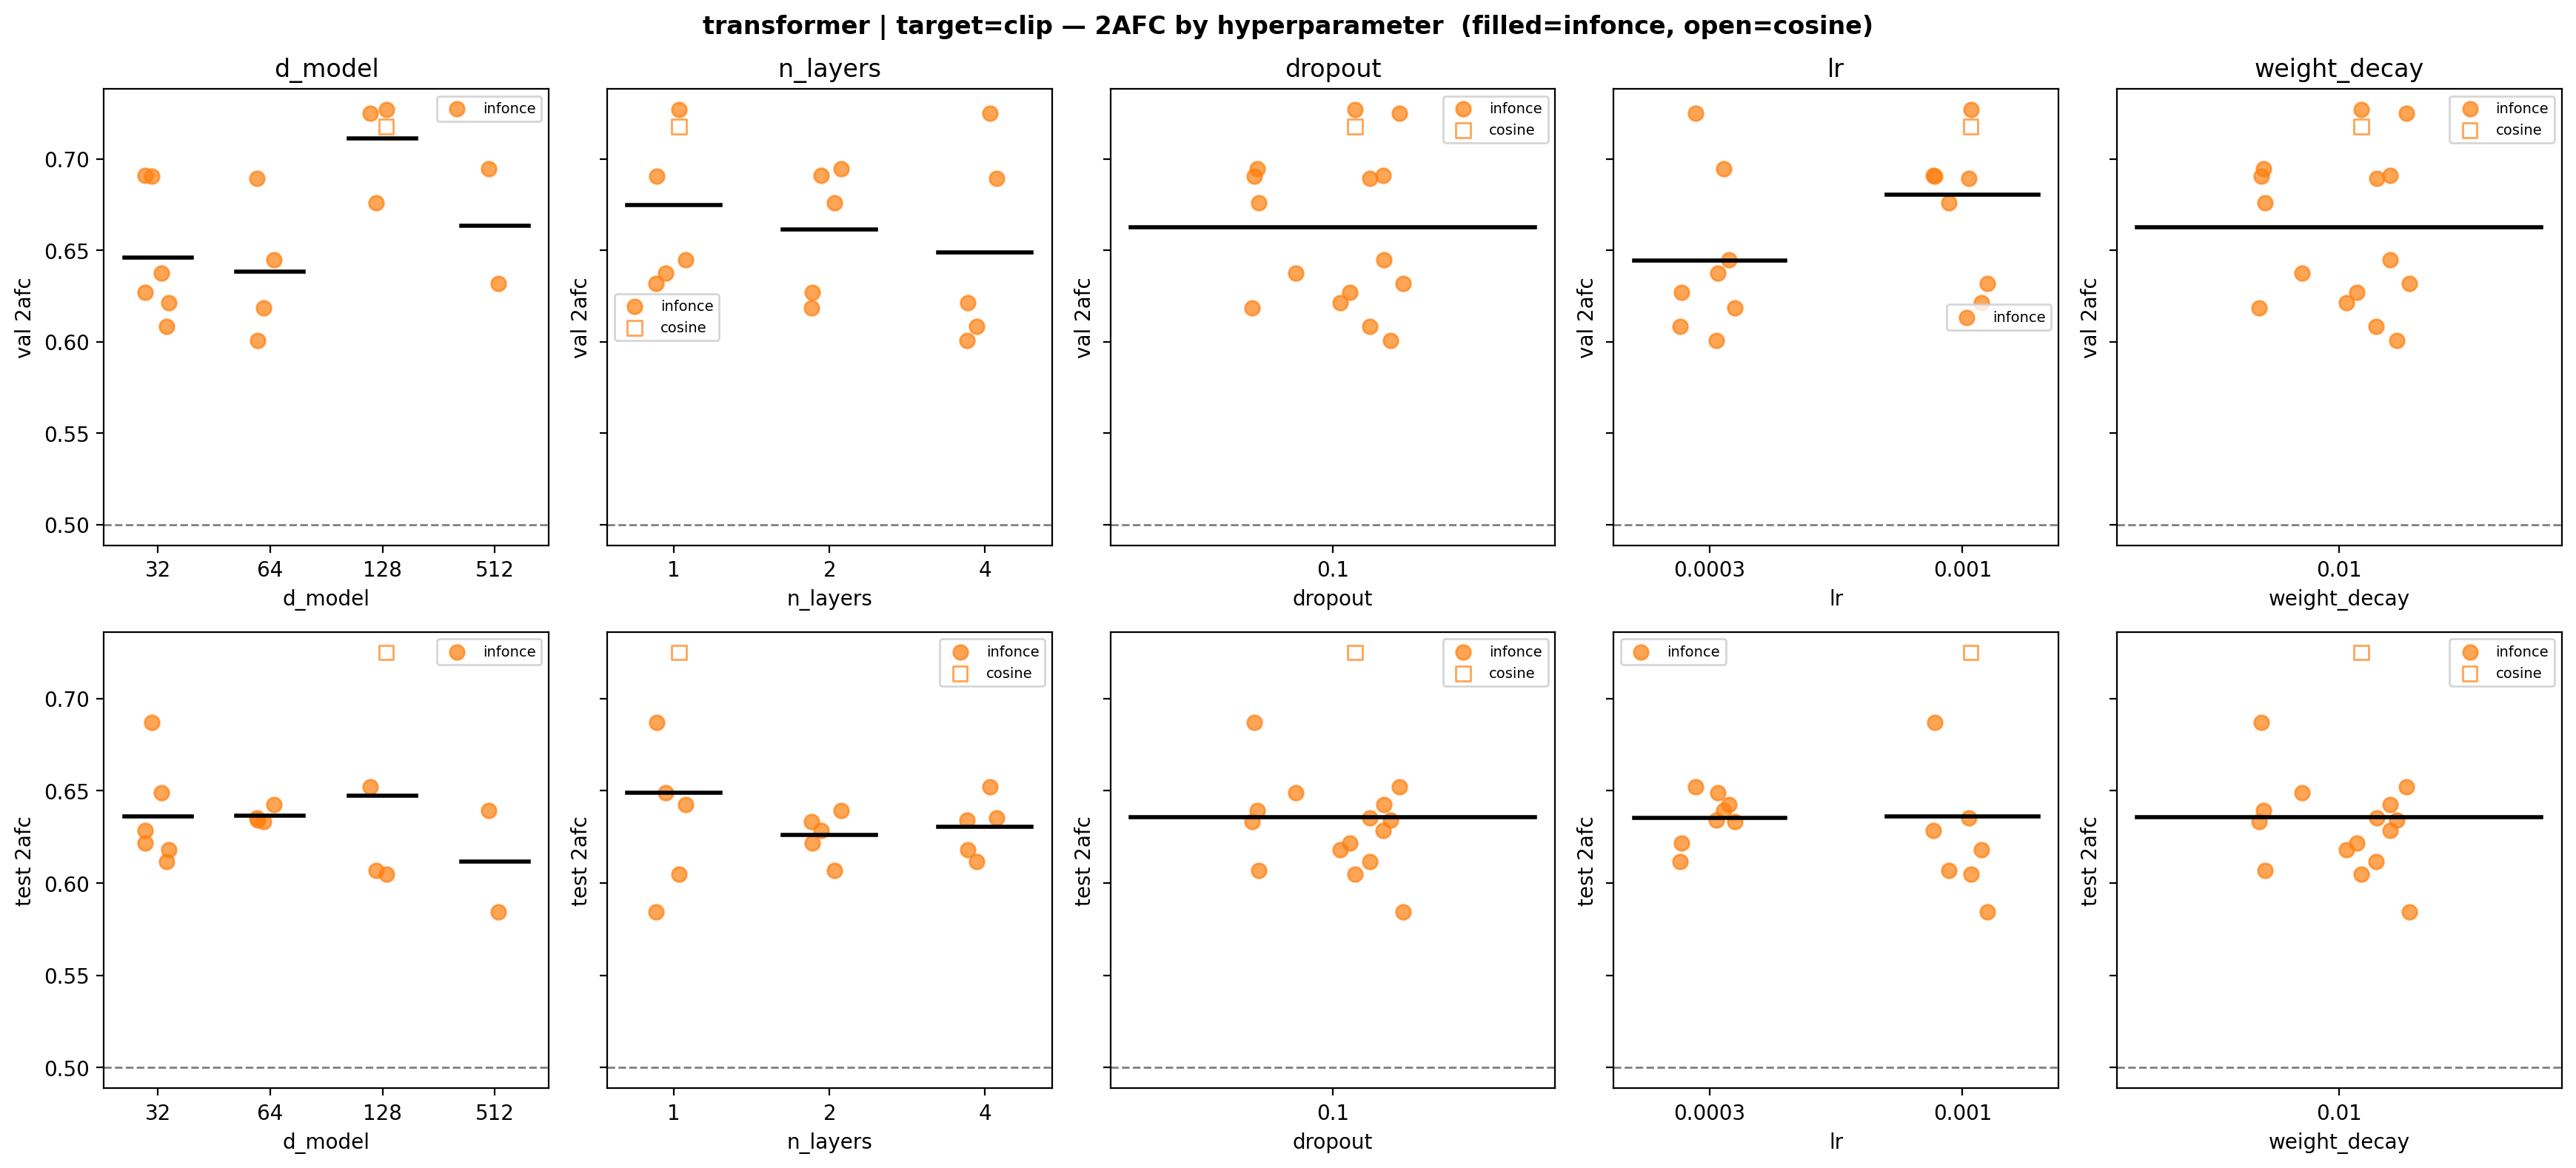

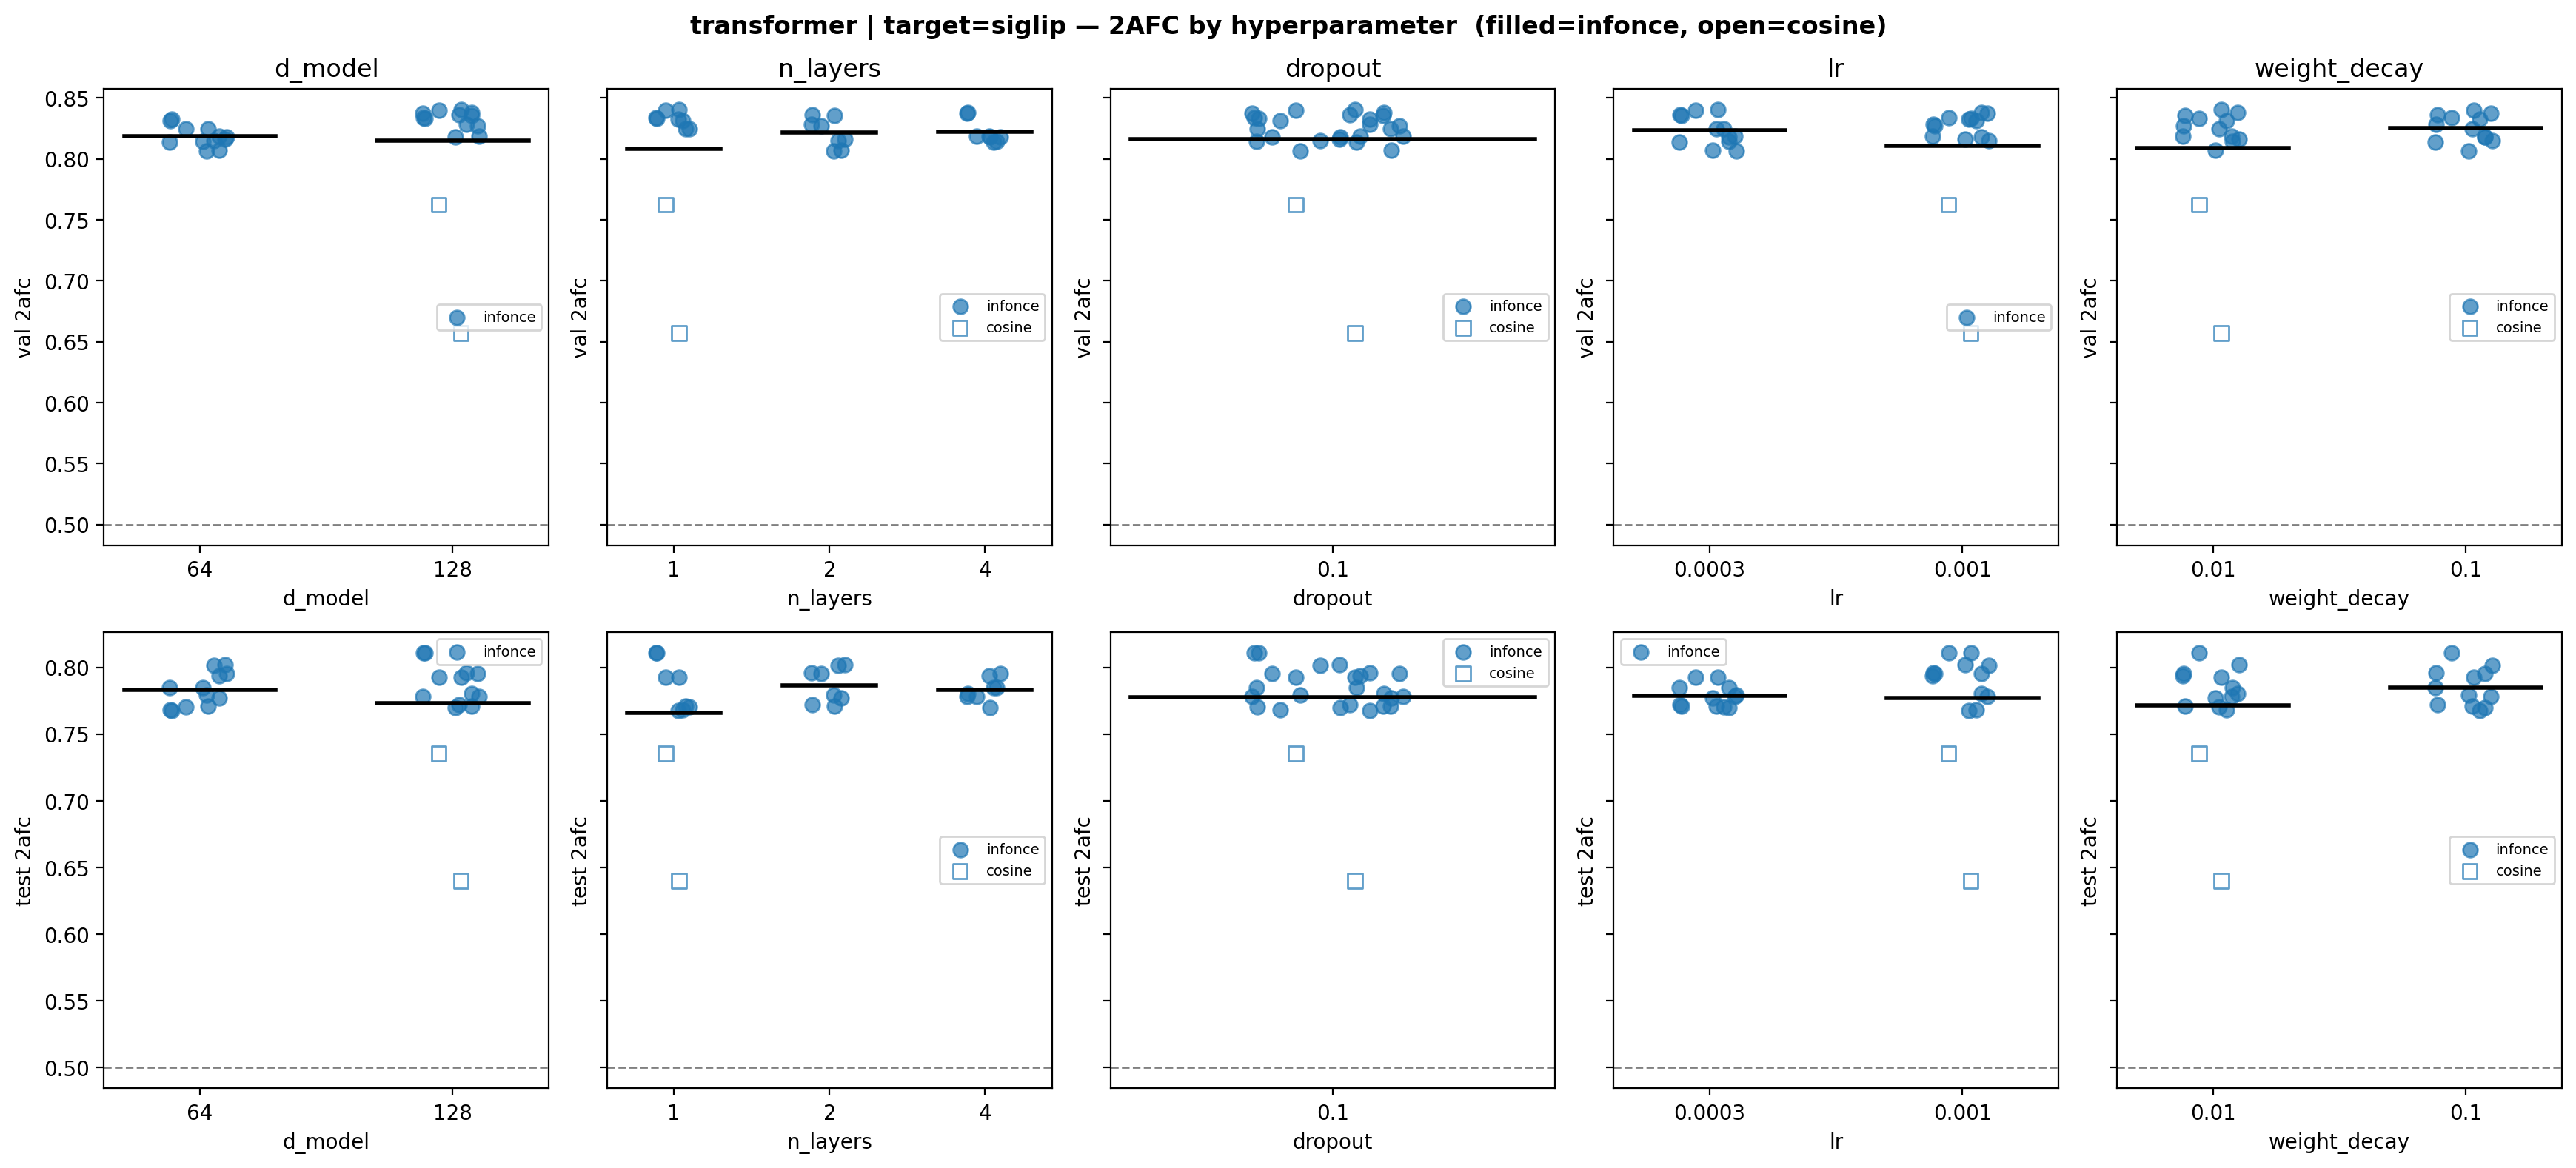

In [18]:
def strip_plot(ax, grp, x_col, title, color="tab:blue", metric_col="val_2afc"):
    levels = sorted(grp[x_col].unique())
    for i, lvl in enumerate(levels):
        for loss, ls in LOSS_STYLE.items():
            vals = grp.loc[(grp[x_col] == lvl) & (grp["loss"] == loss), metric_col].values
            if len(vals) == 0:
                continue
            jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
            fc = color if ls["facecolor"] is None else "none"
            ax.scatter(np.full(len(vals), i) + jitter, vals,
                       alpha=0.7, s=50, color=color, edgecolors=color, facecolors=fc,
                       marker=ls["marker"], label=loss if i == 0 else "_")
        all_vals = grp.loc[grp[x_col] == lvl, metric_col].values
        if len(all_vals):
            ax.plot([i - 0.3, i + 0.3], [all_vals.mean(), all_vals.mean()], "k-", lw=2)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels])
    ax.set_xlabel(x_col)
    ax.set_ylabel(metric_col.replace("_", " "))
    ax.set_title(title)
    ax.axhline(0.5, color="grey", lw=1, ls="--")
    if len(LOSSES) > 1:
        ax.legend(fontsize=7)

metrics_to_plot = ["val_2afc"] + (["test_2afc"] if has_test else [])

for model_name in ENCODER_MODELS:
    for tgt in TARGETS:
        sub = df[(df["model"] == model_name) & (df["target"] == tgt)]
        if sub.empty:
            continue
        hparams = [p for p in SWEEP_PARAMS.get((model_name, tgt), {}) if p in sub.columns]
        if not hparams:
            continue
        n_metrics = len(metrics_to_plot)
        fig, axes = plt.subplots(n_metrics, len(hparams),
                                 figsize=(3.5 * len(hparams), 4 * n_metrics),
                                 sharey="row", squeeze=False)
        fig.suptitle(f"{model_name} | target={tgt} — 2AFC by hyperparameter  (filled=infonce, open=cosine)",
                     fontweight="bold")
        for mi, metric in enumerate(metrics_to_plot):
            sub_m = sub.dropna(subset=[metric])
            for ai, col in enumerate(hparams):
                strip_plot(axes[mi, ai], sub_m, col, col if mi == 0 else "",
                           color=TARGET_PALETTE.get(tgt, "tab:blue"), metric_col=metric)
        plt.tight_layout()
        plt.show()

## 2AFC heatmap — LR × weight_decay (val and test)

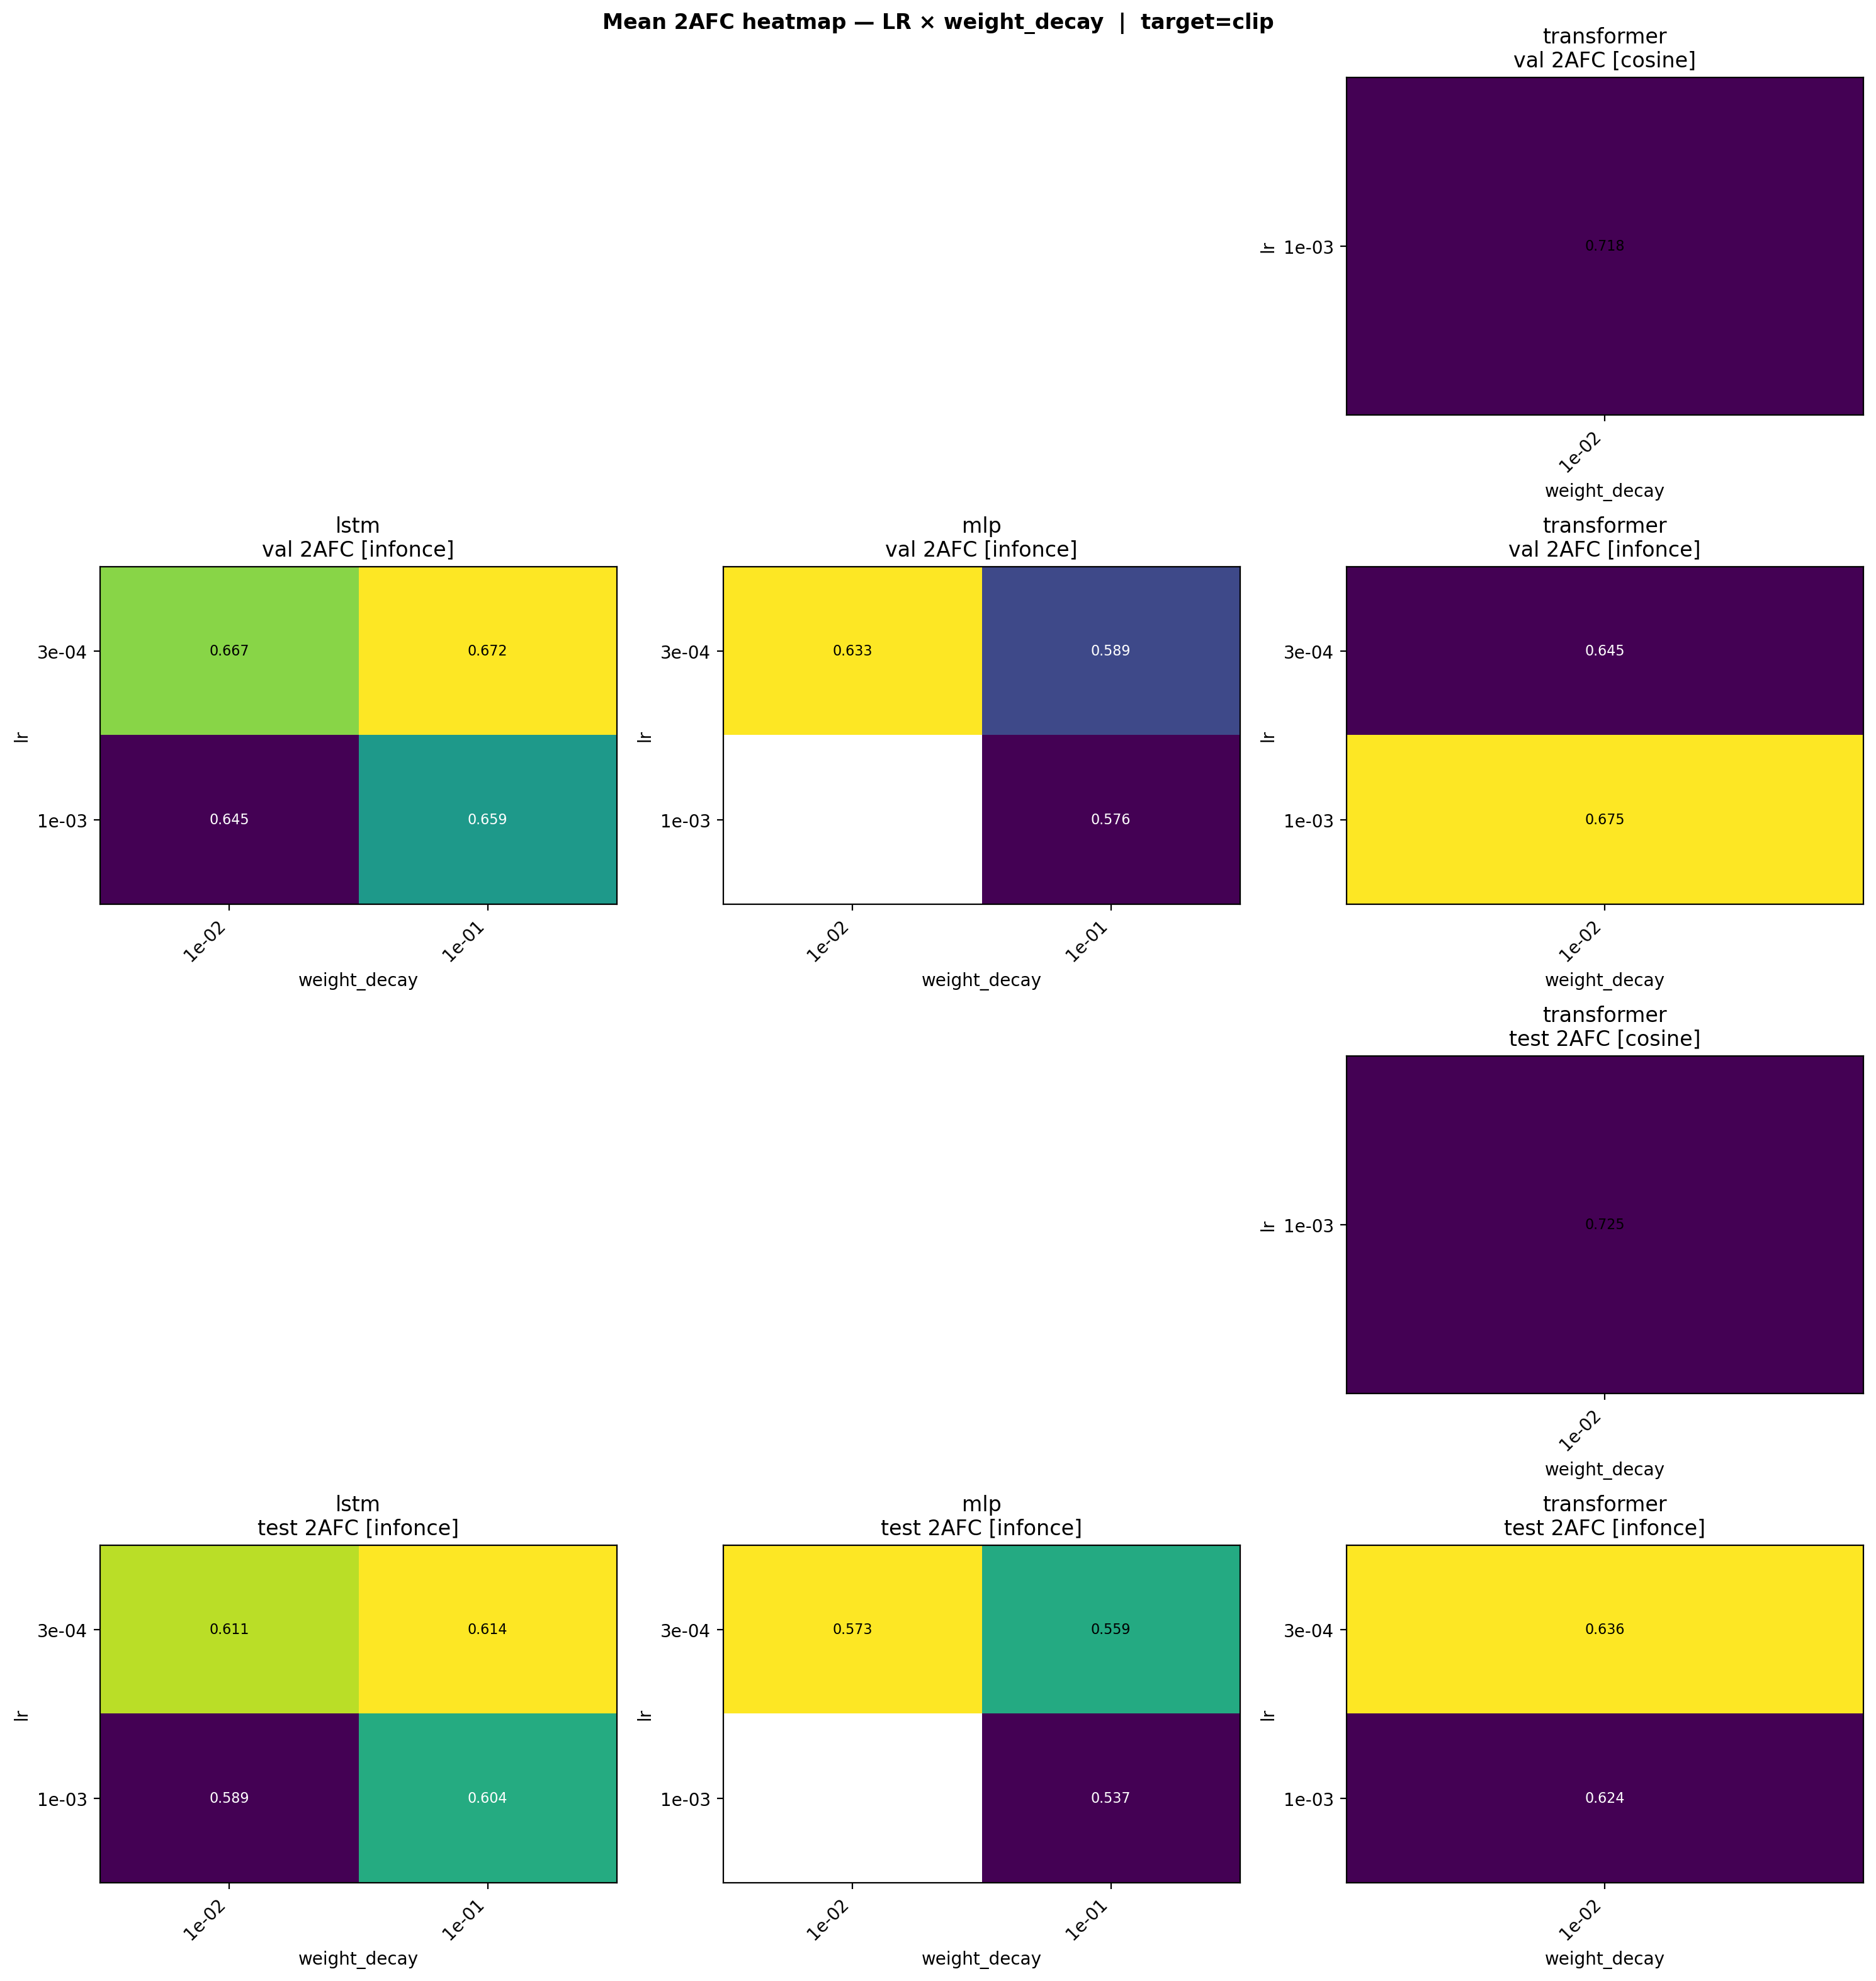

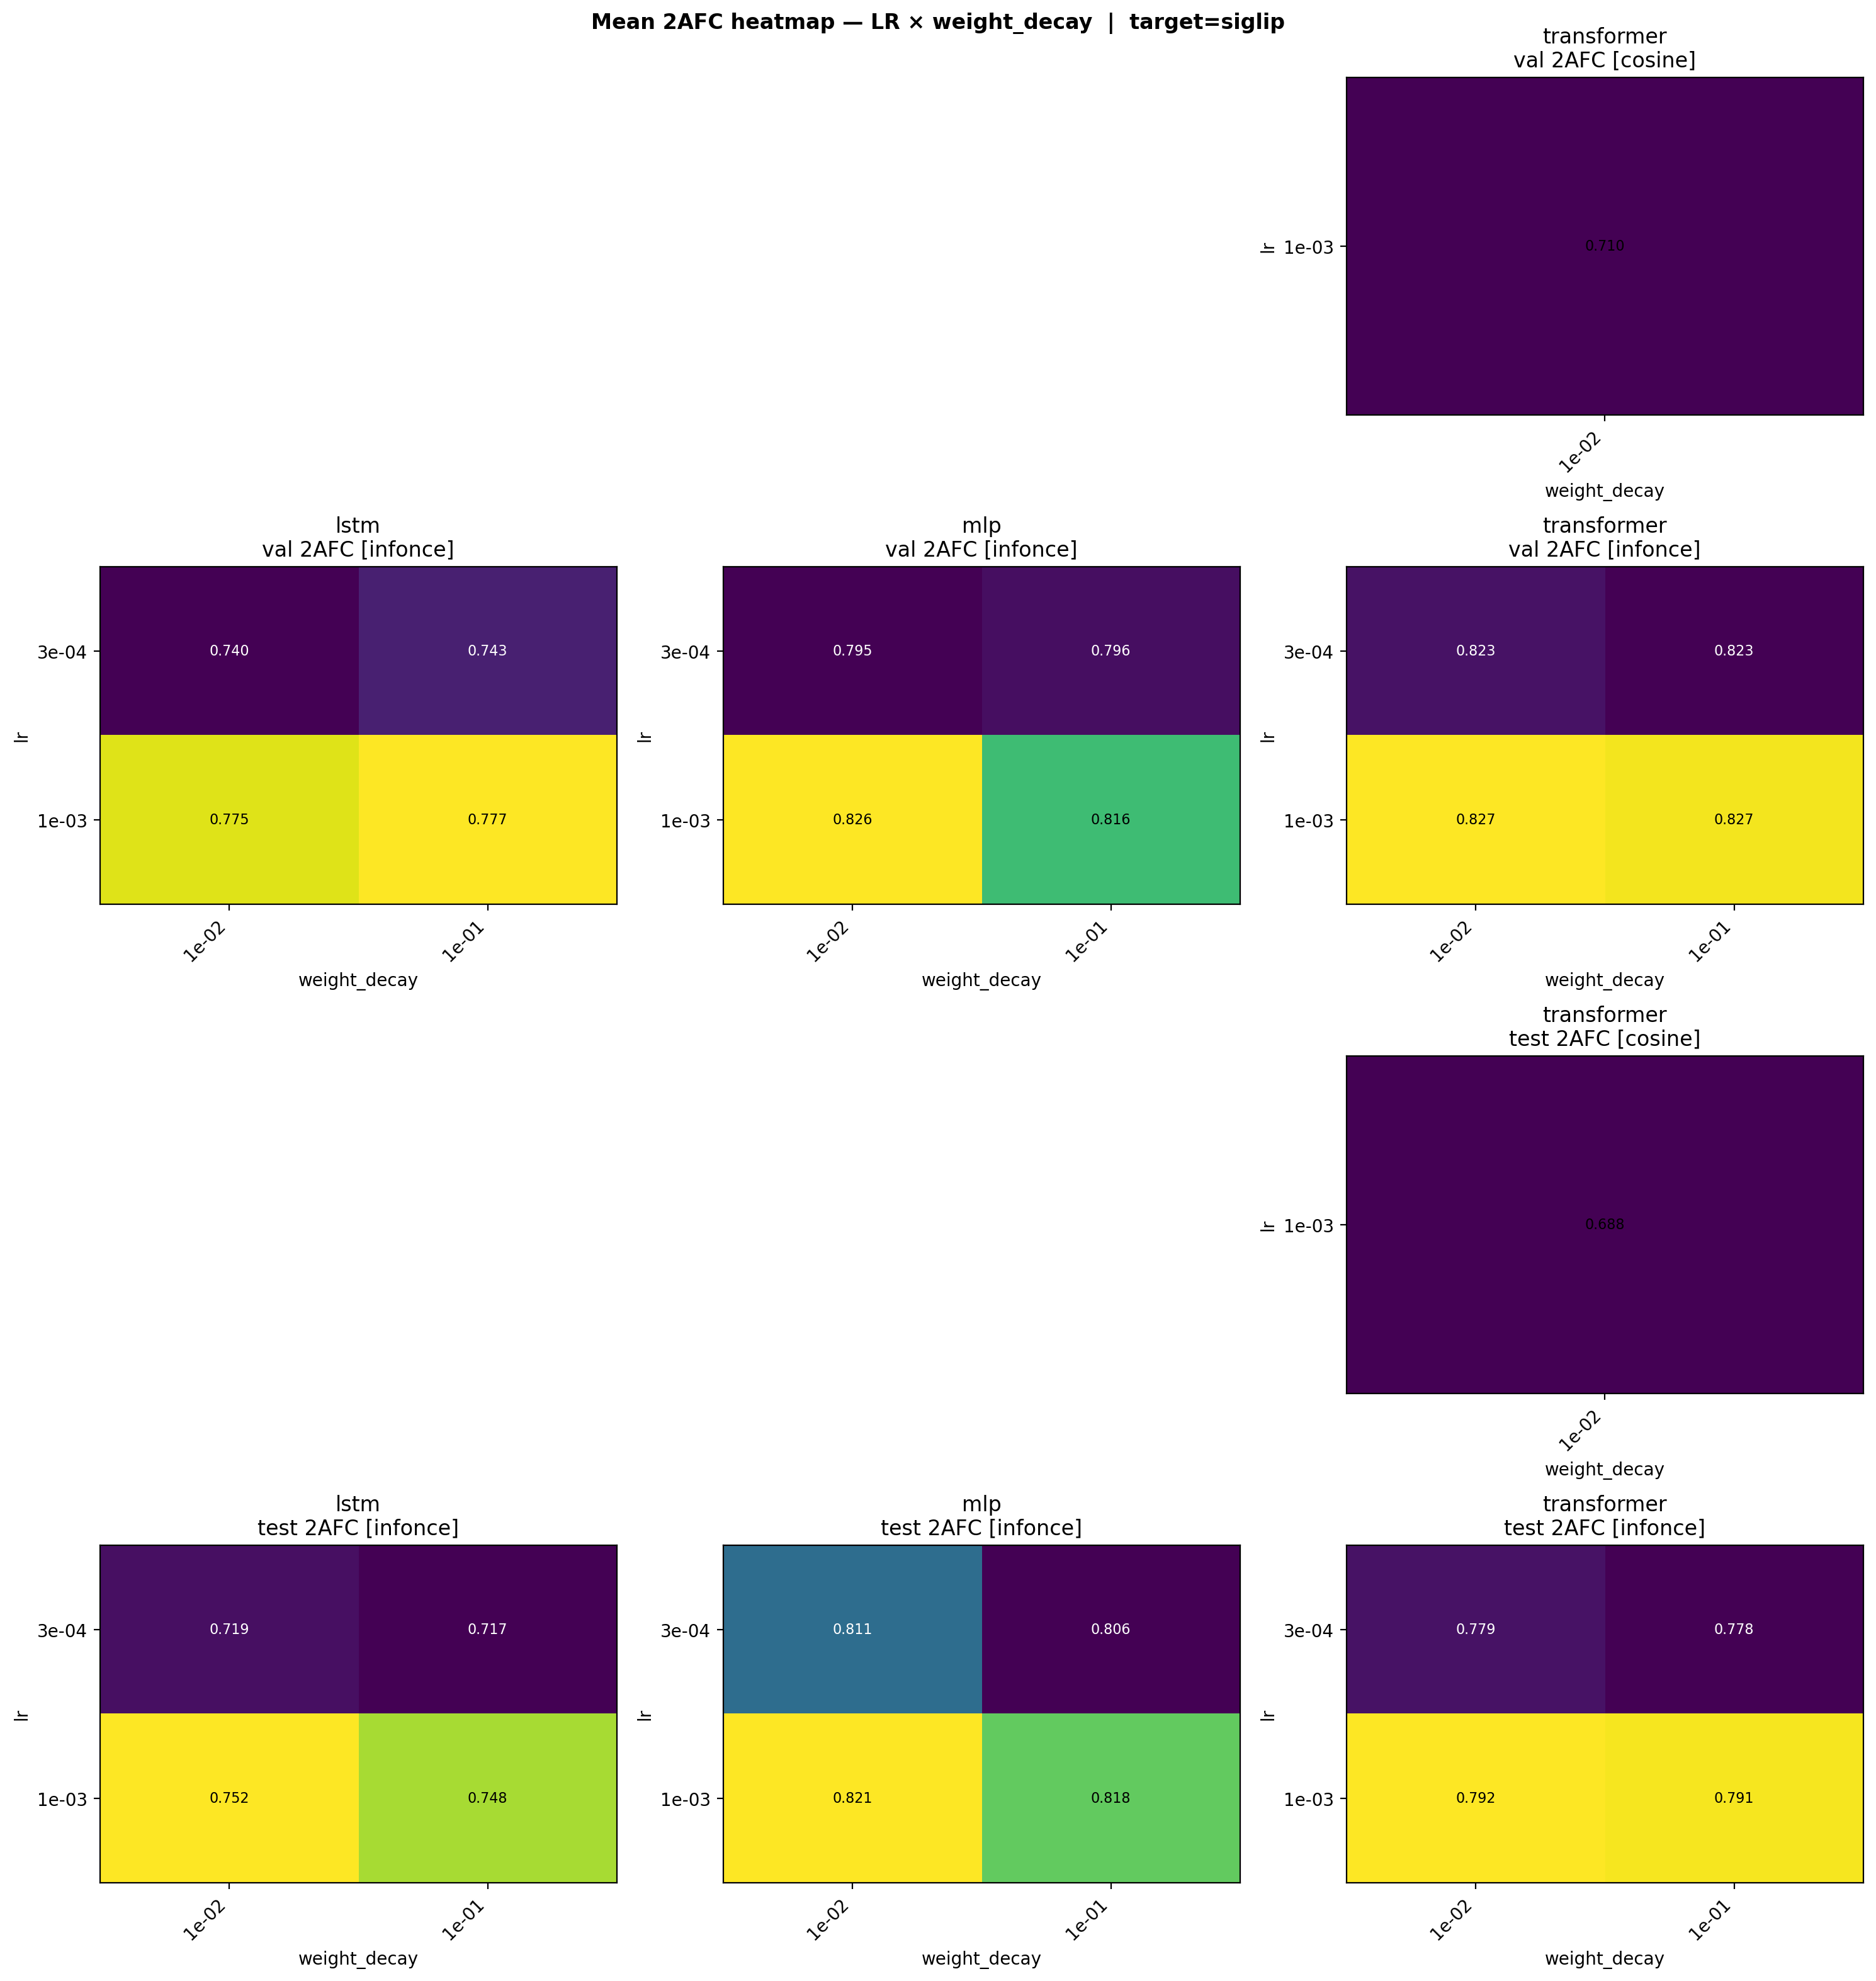

In [19]:
def heatmap(ax, grp, row_col, col_col, val_col, title, cmap="viridis", fmt=".3f"):
    pivot = grp.groupby([row_col, col_col])[val_col].mean().unstack()
    if pivot.empty:
        ax.set_visible(False)
        return
    ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.0e}" for v in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.0e}" for v in pivot.index])
    ax.set_xlabel(col_col)
    ax.set_ylabel(row_col)
    ax.set_title(title)
    mean_val = np.nanmean(pivot.values)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, format(v, fmt), ha="center", va="center", fontsize=8,
                        color="white" if v < mean_val else "black")

heatmap_metrics = [("val_2afc", "val 2AFC")] + ([("test_2afc", "test 2AFC")] if has_test else [])

for tgt in TARGETS:
    sub = df[df["target"] == tgt]
    models_present = [m for m in MODELS if not sub[sub["model"] == m].empty]
    if not models_present:
        continue
    # rows: metric × loss;  cols: model
    row_specs = [(metric_col, metric_label, loss)
                 for metric_col, metric_label in heatmap_metrics
                 for loss in LOSSES]
    fig, axes = plt.subplots(len(row_specs), len(models_present),
                             figsize=(5 * len(models_present), 4 * len(row_specs)),
                             squeeze=False)
    fig.suptitle(f"Mean 2AFC heatmap — LR × weight_decay  |  target={tgt}", fontweight="bold")
    for ri, (metric_col, metric_label, loss) in enumerate(row_specs):
        sub_m = sub[(sub["loss"] == loss)].dropna(subset=[metric_col])
        for ci, model_name in enumerate(models_present):
            grp = sub_m[sub_m["model"] == model_name]
            ax_title = f"{model_name}\n{metric_label} [{loss}]"
            if {"lr", "weight_decay"}.issubset(grp.columns) and len(grp):
                heatmap(axes[ri, ci], grp, "lr", "weight_decay", metric_col, ax_title)
            else:
                axes[ri, ci].set_visible(False)
    plt.tight_layout()
    plt.show()

## Top-10 runs overall

## SigLIP vs CLIP — best-run comparison per model

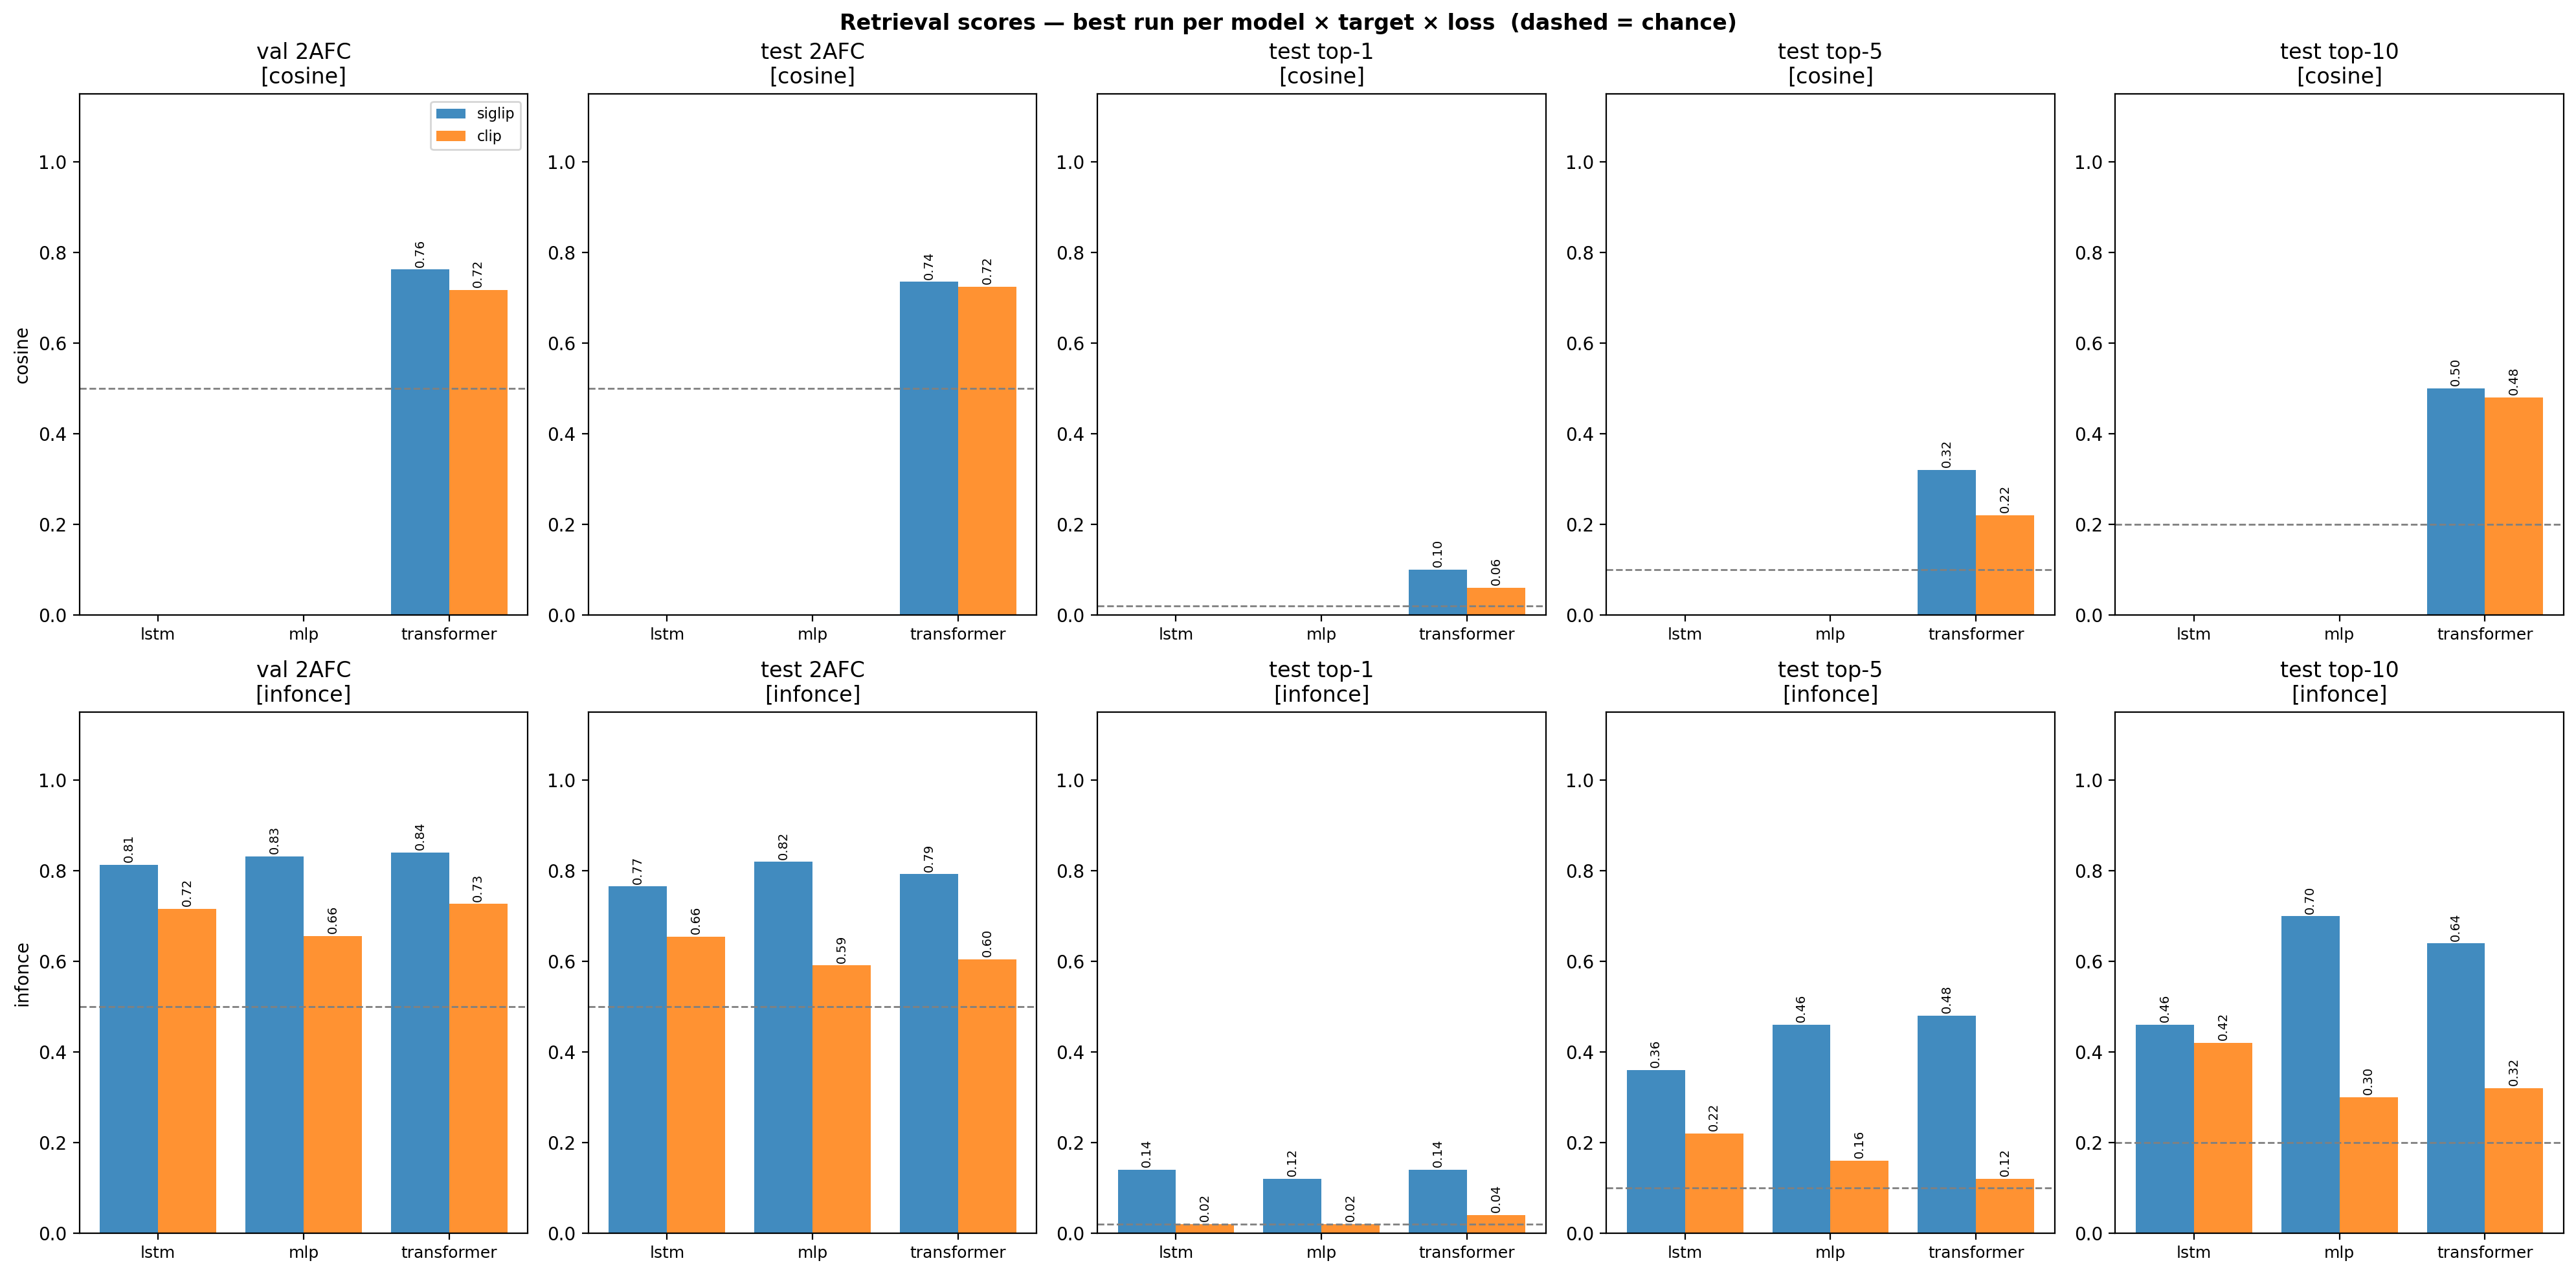

In [20]:
# Best val/test retrieval per (model, target, loss)
best = (
    df.sort_values("val_2afc", ascending=False)
      .groupby(["model", "target", "loss"])
      .first()
      .reset_index()
)

models_list = sorted(best["model"].unique())
x = np.arange(len(models_list))

if has_test:
    bar_metrics = [
        ("val_2afc",   "val 2AFC",   0.50),
        ("test_2afc",  "test 2AFC",  0.50),
        ("test_top1",  "test top-1", 1/50),
        ("test_top5",  "test top-5", 5/50),
        ("test_top10", "test top-10", 10/50),
    ]
    n_cols = len(bar_metrics)
    n_rows = len(LOSSES)
    width = 0.8 / len(["siglip", "clip"])

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 5 * n_rows),
                             sharey=False, squeeze=False)

    for ri, loss in enumerate(LOSSES):
        sub_loss = best[best["loss"] == loss]
        for ci, (metric_col, metric_label, chance) in enumerate(bar_metrics):
            ax = axes[ri, ci]
            for i, tgt in enumerate(["siglip", "clip"]):
                vals = [sub_loss.loc[(sub_loss["model"] == m) & (sub_loss["target"] == tgt), metric_col].values
                        for m in models_list]
                heights = [float(v[0]) if len(v) > 0 else 0.0 for v in vals]
                offset = (i - 0.5) * width
                bars = ax.bar(x + offset, heights, width,
                              label=tgt, color=TARGET_PALETTE.get(tgt, "grey"), alpha=0.85)
                for bar, h in zip(bars, heights):
                    if h > 0:
                        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                                f"{h:.2f}", ha="center", va="bottom", fontsize=7, rotation=90)
            ax.axhline(chance, color="grey", lw=1, ls="--")
            ax.set_xticks(x)
            ax.set_xticklabels(models_list, fontsize=9)
            ax.set_title(f"{metric_label}\n[{loss}]")
            ax.set_ylim(0, 1.15)
            if ci == 0:
                ax.set_ylabel(loss)
            if ri == 0 and ci == 0:
                ax.legend(fontsize=8)

    fig.suptitle("Retrieval scores — best run per model × target × loss  (dashed = chance)",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    width = 0.35 / len(LOSSES)
    fig, axes = plt.subplots(1, len(LOSSES), figsize=(7 * len(LOSSES), 4), sharey=True)
    if len(LOSSES) == 1:
        axes = [axes]
    for ax, loss in zip(axes, LOSSES):
        sub_loss = best[best["loss"] == loss]
        for i, tgt in enumerate(["siglip", "clip"]):
            vals = [sub_loss.loc[(sub_loss["model"] == m) & (sub_loss["target"] == tgt), "val_2afc"].values
                    for m in models_list]
            heights = [float(v[0]) if len(v) > 0 else 0.0 for v in vals]
            bars = ax.bar(x + (i - 0.5) * width, heights, width,
                          label=tgt, color=TARGET_PALETTE.get(tgt, "grey"), alpha=0.85)
            for bar, h in zip(bars, heights):
                if h > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                            f"{h:.3f}", ha="center", va="bottom", fontsize=8)
        ax.axhline(0.5, color="grey", lw=1, ls="--", label="chance")
        ax.set_xticks(x)
        ax.set_xticklabels(models_list)
        ax.set_ylabel("Best val 2AFC")
        ax.set_title(f"loss = {loss}")
        ax.legend()
    fig.suptitle("SigLIP vs CLIP — best run per model", fontweight="bold")
    plt.tight_layout()
    plt.show()

In [21]:
top10_cols = [c for c in ["target", "model", "loss", "arch", "dropout", "lr", "weight_decay",
                          "epoch", "val_loss", "val_2afc",
                          "test_2afc", "test_top1", "test_top5", "test_top10"]
              if c in df.columns]
df[df['target'] == 'siglip'].sort_values("val_2afc", ascending=False)[top10_cols].head(10).reset_index(drop=True)

,target,model,loss,arch,dropout,lr,weight_decay,epoch,val_loss,val_2afc,test_2afc,test_top1,test_top5,test_top10
0,siglip,transformer,infonce,d128_nl1,0.1,0.0003,0.01,92,3.255998,0.840408,0.792653,0.14,0.48,0.64
1,siglip,transformer,infonce,d128_nl1,0.1,0.0003,0.10,92,3.254954,0.840000,0.792653,0.14,0.48,0.64
2,siglip,transformer,infonce,d128_nl4,0.1,0.0010,0.01,40,3.139196,0.837959,0.780408,0.12,0.40,0.56
3,siglip,transformer,infonce,d128_nl4,0.1,0.0010,0.10,40,3.140392,0.837143,0.778367,0.12,0.40,0.56
4,siglip,transformer,infonce,d128_nl2,0.1,0.0003,0.10,65,3.241829,0.836327,0.772245,0.14,0.40,0.50
5,siglip,transformer,infonce,d128_nl2,0.1,0.0003,0.01,65,3.242239,0.835510,0.771020,0.14,0.40,0.50
6,siglip,transformer,infonce,d128_nl1,0.1,0.0010,0.10,110,3.301030,0.833469,0.810612,0.14,0.40,0.64
7,siglip,transformer,infonce,d128_nl1,0.1,0.0010,0.01,110,3.302316,0.833061,0.811020,0.14,0.42,0.66
8,siglip,mlp,infonce,bn256,0.1,0.0010,0.01,108,3.337417,0.832245,0.819592,0.12,0.46,0.70
9,siglip,transformer,infonce,d64_nl1,0.1,0.0010,0.10,35,3.260645,0.832245,0.767755,0.10,0.28,0.60


In [22]:
df[df['target'] == 'clip'].sort_values("val_2afc", ascending=False)[top10_cols].head(10).reset_index(drop=True)

,target,model,loss,arch,dropout,lr,weight_decay,epoch,val_loss,val_2afc,test_2afc,test_top1,test_top5,test_top10
0,clip,transformer,infonce,d128_nl1,0.1,0.0010,0.01,74,39.360542,0.726939,0.604898,0.04,0.12,0.32
1,clip,transformer,infonce,d128_nl4,0.1,0.0003,0.01,81,30.035397,0.724898,0.652245,0.00,0.16,0.38
2,clip,transformer,cosine,d128_nl1,0.1,0.0010,0.01,32,0.640116,0.717551,0.724898,0.06,0.22,0.48
3,clip,lstm,infonce,h128,0.1,0.0010,0.01,60,41.448837,0.716327,0.655102,0.02,0.22,0.42
4,clip,lstm,infonce,h128,0.1,0.0010,0.10,51,37.954845,0.708980,0.664082,0.04,0.26,0.38
5,clip,lstm,infonce,h256,0.1,0.0010,0.10,85,45.251633,0.708980,0.591837,0.04,0.18,0.26
6,clip,lstm,infonce,h256,0.1,0.0003,0.10,123,34.062057,0.705306,0.610204,0.06,0.18,0.24
7,clip,lstm,infonce,h512,0.1,0.0003,0.10,103,38.317886,0.700816,0.675102,0.02,0.22,0.36
8,clip,lstm,infonce,h256,0.1,0.0003,0.10,81,34.917778,0.700408,0.637959,0.00,0.16,0.44
9,clip,lstm,infonce,h256,0.1,0.0003,0.01,122,36.658478,0.698367,0.633469,0.04,0.18,0.34


In [23]:
import json
from config_const import CACHE_DIR

# Save best encoder config per target to a JSON file that other scripts can load.
best_configs = {}
for tgt in ENCODER_TARGETS:
    sub = df[df["target"] == tgt]
    if sub.empty:
        continue
    best_row = sub.sort_values("val_2afc", ascending=False).iloc[0]
    # Extract only the args needed to reconstruct the model + its checkpoint path
    config = {
        "target": tgt,
        "model": best_row["model"],
        "val_2afc": float(best_row["val_2afc"]),
        "checkpoint": best_row["path"],
    }
    # Model-specific architecture params
    if best_row["model"] == "mlp":
        config["bottleneck"] = int(best_row["bottleneck"])
    elif best_row["model"] == "lstm":
        config["hidden"] = int(best_row["hidden"])
        config["n_layers"] = int(best_row["n_layers"])
    elif best_row["model"] == "transformer":
        config["d_model"] = int(best_row["d_model"])
        config["n_heads"] = int(best_row["n_heads"])
        config["n_layers"] = int(best_row["n_layers"])
    # Shared training params
    config["dropout"] = float(best_row["dropout"])
    config["lr"] = float(best_row["lr"])
    config["weight_decay"] = float(best_row["weight_decay"])
    best_configs[tgt] = config

out_path = CACHE_DIR / "best_encoder_config.json"
with open(out_path, "w") as f:
    json.dump(best_configs, f, indent=2)

print(f"Saved to {out_path}")
for tgt, cfg in best_configs.items():
    print(f"  {tgt}: {cfg['model']} — val_2afc={cfg['val_2afc']:.4f}")
    print(f"    {cfg['checkpoint']}")

Saved to /home/yy3658/NeurObjectGen/cache/best_encoder_config.json
  siglip: transformer — val_2afc=0.8404
    /home/yy3658/NeurObjectGen/checkpoints/transformer/siglip/d128_nh4_nl1_do0.1_lr0.0003_wd0.01_tn0.02_bs64_t0.07_uw0.1/best.pt
  clip: transformer — val_2afc=0.7269
    /home/yy3658/NeurObjectGen/checkpoints/transformer/clip/d128_nh4_nl1_do0.1_lr0.001_wd0.01_tn0.02_bs64_t0.07_uw0.1/best.pt
